# Notebook 05 — Spatiotemporal Air-Quality Analysis
## การวิเคราะห์ PM₂.₅ เชิงเวลาและเชิงพื้นที่ พ.ศ. 2021–2025

**ระดับผู้เรียน:** ปริญญาตรีปี 3–4 / ปริญญาโท  
**กลุ่มสาขา:** สิ่งแวดล้อม ภูมิศาสตร์ ภูมิสารสนเทศ อุตุนิยมวิทยา  
**Platform:** Google Colab

---

# บทบาทของ Notebook 05

Notebook 02 ทำให้เราได้:

```text
PM2.5 daily observations
```

Notebook 03 ทำให้เราเข้าใจ:

```text
Point
Polygon
CRS
GeoDataFrame
```

Notebook 04 ทำให้เราได้:

```text
administrative spatial join
nearest WMO candidate
distance
```

Notebook 05 จะรวม:

```text
Where
+
When
+
How much
```

เพื่อวิเคราะห์:

```text
PM2.5 variation in time
+
monitoring-station geography
```

---

# Workflow

```text
Daily PM2.5
      +
PCD station geometry
      ↓
Station-day GeoDataFrame
      ↓
Completeness QC
      ↓
Station-year summaries
      ↓
Station-month summaries
      ↓
Annual variation 2021–2025
      ↓
Monthly variation
      ↓
Dry / Wet / May transition
      ↓
Three-province comparison
      ↓
High-PM2.5 episode identification
      ↓
Same-scale annual maps
      ↓
Scientific interpretation
```

# Learning Outcomes

เมื่อจบ Notebook นี้ นิสิตควรสามารถ:

1. เชื่อม time-series table กับ station geometry
2. สร้าง station-day GeoDataFrame
3. คำนวณ station-year completeness
4. อธิบาย calendar-year completeness ได้
5. แยก completeness metric ออกจาก pollutant value
6. สร้าง annual station summaries
7. สร้าง monthly station summaries
8. เปรียบเทียบ annual variation 2021–2025
9. วิเคราะห์ monthly distribution
10. ใช้ season classification สำหรับการสอนอย่างโปร่งใส
11. วิเคราะห์ Dry (Nov–Apr), Wet (Jun–Oct) และ May transition
12. เปรียบเทียบ Saraburi, Lop Buri และ Nakhon Nayok
13. สร้าง annual station maps ด้วย scale เดียวกันทุกปี
14. อธิบายว่าทำไม map scale ต้องคงที่เมื่อเปรียบเทียบหลายปี
15. สร้าง data-availability maps
16. ตรวจการเปลี่ยนแปลงของ monitoring network
17. นิยาม high-PM₂.₅ episode ด้วย percentile เพื่อการสำรวจ
18. แยก percentile event definition ออกจาก regulatory exceedance
19. สร้าง high-episode station map
20. เชื่อม nearest-WMO distance เป็น network metadata
21. อธิบายข้อจำกัดของ point-monitoring network
22. เตรียมข้อมูลสำหรับ spatial statistics ใน Notebook 06

# 5.1 Scientific Principles

## Principle 1 — Spatial pattern depends on station availability

ถ้าปีหนึ่งมี 25 สถานี แต่ปีหนึ่งมี 60 สถานี

ค่าเฉลี่ยระดับ network อาจเปลี่ยนเพราะ:

```text
atmosphere/environment
+
monitoring network composition
```

ดังนั้นทุก summary ต้องมี:

```text
station_n
station_day_n
coverage
```

---

## Principle 2 — Point observations are not continuous surfaces

แผนที่ Point บอก:

> ค่าที่สถานีตรวจวัด

ไม่ได้บอก:

> ค่าทุกตำแหน่งระหว่างสถานี

---

## Principle 3 — 2021–2025 is not automatically a climatology

ใน Notebook นี้ใช้คำว่า:

```text
2021–2025 teaching period
multi-year variation
```

ไม่เรียกว่า climatology โดยอัตโนมัติ

---

## Principle 4 — Same map scale for honest year-to-year comparison

หากปี 2021 ใช้:

```text
0–40
```

แต่ปี 2025 ใช้:

```text
0–100
```

สีเดียวกันอาจหมายถึงค่าต่างกัน

ดังนั้น annual maps ในบทนี้จะใช้:

```text
common vmin
common vmax
```

ทุกปี

# 5.2 Seasonal Classification Used in This Course

เพื่อการสอน เราจะใช้:

```text
Dry season:
November–April

Wet season:
June–October

Transition:
May
```

ดังนั้น May จะ **ไม่ถูกบังคับ** เข้า dry หรือ wet season

นี่เป็น **teaching classification**
สำหรับการเปรียบเทียบเชิงสำรวจ

ไม่ควรตีความว่าเป็นนิยามฤดูกาลที่ใช้ได้เหมือนกันทุกพื้นที่ ทุกปี และทุกงานวิจัย

In [50]:
# CELL 1 — Install packages

!pip -q install -U \
    pandas \
    geopandas \
    pyogrio \
    shapely \
    pyproj \
    pyarrow \
    openpyxl

In [51]:
# CELL 2 — Mount Google Drive

from google.colab import drive

drive.mount(
    "/content/drive",
    force_remount=False
)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [52]:
# CELL 3 — Imports

from pathlib import Path
import calendar
import warnings

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

warnings.filterwarnings(
    "ignore",
    category=RuntimeWarning
)

print(
    "pandas:",
    pd.__version__
)

print(
    "GeoPandas:",
    gpd.__version__
)

pandas: 3.0.5
GeoPandas: 1.1.4


# 5.3 Input Data

Notebook นี้ใช้:

จาก Notebook 01:

```text
environmental_gis_course.gpkg
```

จาก Notebook 02:

```text
02_pcd_pm25_daily_2021_2025.csv.gz
```

จาก Notebook 04:

```text
04_national_PCD_WMO_nearest_geodesic.csv
```

ไฟล์จาก Notebook 04 เป็น **optional input**

ถ้าไม่มี Notebook 05 ยังวิเคราะห์ PM₂.₅ ได้
เพียงข้ามส่วน nearest-WMO network context

In [53]:
# CELL 4 — Paths

DATASET_VERSION = "v1"

BASE_DIR = Path(
    "/content/drive/MyDrive/"
    "Teaching_PCD_Environmental_GIS"
)

DATASET_DIR = (
    BASE_DIR
    / "01_course_data"
    / DATASET_VERSION
    / "dataset"
)

NOTEBOOK02_OUTPUT = (
    BASE_DIR
    / "02_output"
    / "Notebook_02"
)

NOTEBOOK04_OUTPUT = (
    BASE_DIR
    / "02_output"
    / "Notebook_04"
)

OUTPUT_DIR = (
    BASE_DIR
    / "02_output"
    / "Notebook_05"
)

FIGURE_DIR = (
    BASE_DIR
    / "03_figures"
    / "Notebook_05"
)


for folder in [
    OUTPUT_DIR,
    FIGURE_DIR,
]:
    folder.mkdir(
        parents=True,
        exist_ok=True
    )


print(
    "Dataset:",
    DATASET_DIR
)

print(
    "\nNotebook 05 output:",
    OUTPUT_DIR
)

Dataset: /content/drive/MyDrive/Teaching_PCD_Environmental_GIS/01_course_data/v1/dataset

Notebook 05 output: /content/drive/MyDrive/Teaching_PCD_Environmental_GIS/02_output/Notebook_05


In [54]:
# CELL 5 — Locate required files

def find_unique_file(
    root,
    filename,
    required=True,
):
    root = Path(
        root
    )

    if not root.exists():

        if required:

            raise FileNotFoundError(
                f"Folder not found: {root}"
            )

        return None

    matches = list(
        root.rglob(
            filename
        )
    )

    if len(
        matches
    ) == 1:

        return matches[
            0
        ]

    if len(
        matches
    ) == 0:

        if required:

            raise FileNotFoundError(
                f"Required file not found: {filename}"
            )

        return None

    raise RuntimeError(
        f"Multiple files found for {filename}: "
        + str(
            matches
        )
    )


COURSE_GPKG = find_unique_file(
    DATASET_DIR,
    "environmental_gis_course.gpkg",
)

PM25_DAILY_FILE = find_unique_file(
    NOTEBOOK02_OUTPUT,
    "02_pcd_pm25_daily_2021_2025.csv.gz",
)

NEAREST_WMO_FILE = find_unique_file(
    NOTEBOOK04_OUTPUT,
    "04_national_PCD_WMO_nearest_geodesic.csv",
    required=False,
)


print(
    "GeoPackage:",
    COURSE_GPKG
)

print(
    "\nPM2.5 daily:",
    PM25_DAILY_FILE
)

print(
    "\nNearest WMO metadata:",
    NEAREST_WMO_FILE
)

GeoPackage: /content/drive/MyDrive/Teaching_PCD_Environmental_GIS/01_course_data/v1/dataset/processed/environmental_gis_course.gpkg

PM2.5 daily: /content/drive/MyDrive/Teaching_PCD_Environmental_GIS/02_output/Notebook_02/02_pcd_pm25_daily_2021_2025.csv.gz

Nearest WMO metadata: /content/drive/MyDrive/Teaching_PCD_Environmental_GIS/02_output/Notebook_04/04_national_PCD_WMO_nearest_geodesic.csv


In [55]:
# CELL 6 — Read GIS layers

province = gpd.read_file(
    COURSE_GPKG,
    layer="province",
)

pcd_stations = gpd.read_file(
    COURSE_GPKG,
    layer="pcd_stations",
)


pcd_stations[
    "station_id"
] = (
    pcd_stations[
        "station_id"
    ]
    .astype(
        "string"
    )
    .str.strip()
    .str.lower()
)


print(
    "Province polygons:",
    len(
        province
    )
)

print(
    "PCD stations:",
    len(
        pcd_stations
    )
)

print(
    "CRS:",
    pcd_stations.crs
)

Province polygons: 77
PCD stations: 173
CRS: EPSG:4326


In [56]:
# CELL 7 — Read PM2.5 daily data

pm25_daily = pd.read_csv(
    PM25_DAILY_FILE,
    dtype={
        "station_id":
            "string"
    },
    parse_dates=[
        "date"
    ],
)


pm25_daily[
    "station_id"
] = (
    pm25_daily[
        "station_id"
    ]
    .astype(
        "string"
    )
    .str.strip()
    .str.lower()
)


required_pm25_fields = [
    "station_id",
    "date",
    "pm25_mean",
]


missing_pm25_fields = [
    field
    for field
    in required_pm25_fields
    if field
    not in pm25_daily.columns
]


if missing_pm25_fields:

    raise KeyError(
        "PM2.5 daily table is missing: "
        + ", ".join(
            missing_pm25_fields
        )
    )


pm25_daily[
    "pm25_mean"
] = pd.to_numeric(
    pm25_daily[
        "pm25_mean"
    ],
    errors="coerce",
)


print(
    "Daily rows:",
    len(
        pm25_daily
    )
)

print(
    "Stations:",
    pm25_daily[
        "station_id"
    ].nunique()
)

print(
    "Date range:",
    pm25_daily[
        "date"
    ].min(),
    "to",
    pm25_daily[
        "date"
    ].max()
)

Daily rows: 70173
Stations: 105
Date range: 2024-01-01 00:00:00 to 2025-12-31 00:00:00


# 5.4 From Station-Day Table to Station-Day GeoDataFrame

PM₂.₅ table มี:

```text
station_id
date
pm25_mean
```

station layer มี:

```text
station_id
geometry
province
latitude
longitude
```

ใช้:

```text
attribute join
```

เพื่อสร้าง:

```text
station-day + geometry
```

หนึ่งสถานีจะมี geometry เดิมซ้ำหลายวัน

นี่เป็นเรื่องปกติสำหรับ spatiotemporal point data

In [57]:
# CELL 8 — Merge geometry into daily PM2.5 records

station_geometry_fields = [
    c
    for c
    in [
        "station_id",
        "station_name_th",
        "station_name_en",
        "province_name_en",
        "province_name_th",
        "amphoe_name_en",
        "tambon_name_en",
        "latitude",
        "longitude",
        "geometry",
    ]
    if c
    in pcd_stations.columns
]


pm25_spatiotemporal = (
    pm25_daily
    .drop(
        columns=[
            c
            for c
            in station_geometry_fields
            if (
                c != "station_id"
                and c
                in pm25_daily.columns
            )
        ],
        errors="ignore",
    )
    .merge(
        pcd_stations[
            station_geometry_fields
        ],
        on="station_id",
        how="left",
        validate="many_to_one",
    )
)


pm25_spatiotemporal = gpd.GeoDataFrame(
    pm25_spatiotemporal,
    geometry="geometry",
    crs=pcd_stations.crs,
)


geometry_match_pct = (
    pm25_spatiotemporal.geometry.notna().mean()
    * 100
)


print(
    "Station-day rows:",
    len(
        pm25_spatiotemporal
    )
)

print(
    "Geometry match:",
    f"{geometry_match_pct:.1f}%"
)

Station-day rows: 70173
Geometry match: 97.4%


In [58]:
# CELL 9 — Spatiotemporal input QC

input_qc = pd.DataFrame([
    {
        "check":
            "station_day_rows",

        "value":
            len(
                pm25_spatiotemporal
            ),
    },

    {
        "check":
            "unique_stations",

        "value":
            pm25_spatiotemporal[
                "station_id"
            ].nunique(),
    },

    {
        "check":
            "missing_geometry_rows",

        "value":
            int(
                pm25_spatiotemporal.geometry.isna().sum()
            ),
    },

    {
        "check":
            "missing_PM25_rows",

        "value":
            int(
                pm25_spatiotemporal[
                    "pm25_mean"
                ]
                .isna()
                .sum()
            ),
    },

    {
        "check":
            "duplicate_station_date_rows",

        "value":
            int(
                pm25_spatiotemporal
                .duplicated(
                    subset=[
                        "station_id",
                        "date",
                    ],
                    keep=False,
                )
                .sum()
            ),
    },
])


display(
    input_qc
)

,check,value
0,station_day_rows,70173
1,unique_stations,105
2,missing_geometry_rows,1833
3,missing_PM25_rows,0
4,duplicate_station_date_rows,0


In [59]:
# CELL 10 — Temporal fields

pm25_spatiotemporal[
    "year"
] = (
    pm25_spatiotemporal[
        "date"
    ]
    .dt.year
)


pm25_spatiotemporal[
    "month"
] = (
    pm25_spatiotemporal[
        "date"
    ]
    .dt.month
)


pm25_spatiotemporal[
    "month_name"
] = (
    pm25_spatiotemporal[
        "date"
    ]
    .dt.month_name()
)


pm25_spatiotemporal[
    "day_of_week"
] = (
    pm25_spatiotemporal[
        "date"
    ]
    .dt.day_name()
)


def teaching_season(
    month,
):
    if month in [
        11,
        12,
        1,
        2,
        3,
        4,
    ]:
        return "Dry (Nov-Apr)"

    if month in [
        6,
        7,
        8,
        9,
        10,
    ]:
        return "Wet (Jun-Oct)"

    if month == 5:
        return "Transition (May)"

    return pd.NA


pm25_spatiotemporal[
    "season_teaching"
] = (
    pm25_spatiotemporal[
        "month"
    ]
    .map(
        teaching_season
    )
)

# 5.5 Station-Year Completeness

สำหรับแต่ละ:

```text
station × year
```

เราคำนวณ:

```text
observed_days
expected_calendar_days
calendar_year_coverage_pct
```

เช่น:

```text
2024 = 366 วัน
```

ถ้ามี 300 วัน:

```text
coverage ≈ 82%
```

---

## Caveat

Calendar-year completeness อาจ penalize สถานีที่:

- เปิดกลางปี
- ปิดกลางปี
- มีการเปลี่ยนระบบ

ดังนั้น metric นี้ใช้เพื่อ:

> เปรียบเทียบ data availability สำหรับการสอนและ exploratory analysis

ไม่ใช่ PCD regulatory completeness criterion

In [60]:
# CELL 11 — Station-year completeness

def days_in_year(
    year,
):
    return (
        366
        if calendar.isleap(
            int(
                year
            )
        )
        else 365
    )


station_year_coverage = (
    pm25_spatiotemporal
    .groupby(
        [
            "station_id",
            "year",
        ]
    )
    .agg(
        observed_days=(
            "date",
            "nunique",
        ),

        pm25_non_missing_days=(
            "pm25_mean",
            "count",
        ),

        date_min=(
            "date",
            "min",
        ),

        date_max=(
            "date",
            "max",
        ),
    )
    .reset_index()
)


station_year_coverage[
    "expected_calendar_days"
] = (
    station_year_coverage[
        "year"
    ]
    .map(
        days_in_year
    )
)


station_year_coverage[
    "calendar_year_coverage_pct"
] = (
    station_year_coverage[
        "pm25_non_missing_days"
    ]
    /
    station_year_coverage[
        "expected_calendar_days"
    ]
    * 100
)


display(
    station_year_coverage.head(
        20
    )
)

,station_id,year,observed_days,pm25_non_missing_days,date_min,date_max,expected_calendar_days,calendar_year_coverage_pct
0,02t,2024,366,366,2024-01-01,2024-12-31,366,100.000000
1,02t,2025,361,361,2025-01-01,2025-12-31,365,98.904110
2,03t,2024,356,356,2024-01-01,2024-12-31,366,97.267760
3,03t,2025,361,361,2025-01-01,2025-12-31,365,98.904110
4,05t,2024,351,351,2024-01-01,2024-12-31,366,95.901639
5,05t,2025,357,357,2025-01-01,2025-12-31,365,97.808219
6,08t,2024,363,363,2024-01-01,2024-12-31,366,99.180328
7,08t,2025,355,355,2025-01-01,2025-12-28,365,97.260274
8,100t,2024,361,361,2024-01-01,2024-12-31,366,98.633880
9,100t,2025,365,365,2025-01-01,2025-12-31,365,100.000000


# Teaching Completeness Threshold

สำหรับ annual comparison ในบทนี้ ตั้ง parameter:

```text
MIN_ANNUAL_COVERAGE_PCT = 75%
```

จุดประสงค์:

```text
สร้าง subset ที่มีข้อมูลค่อนข้างครบ
```

ไม่ใช่:

```text
เกณฑ์มาตรฐานทางกฎหมาย
```

เราจะเก็บทั้ง:

```text
all station-years
eligible station-years
```

เพื่อดูผลของ completeness filtering

In [61]:
# CELL 12 — Teaching completeness flag

MIN_ANNUAL_COVERAGE_PCT = 75.0


station_year_coverage[
    "annual_coverage_eligible"
] = (
    station_year_coverage[
        "calendar_year_coverage_pct"
    ]
    >= MIN_ANNUAL_COVERAGE_PCT
)


coverage_summary_by_year = (
    station_year_coverage
    .groupby(
        "year"
    )
    .agg(
        station_n=(
            "station_id",
            "nunique",
        ),

        eligible_station_n=(
            "annual_coverage_eligible",
            "sum",
        ),

        median_coverage_pct=(
            "calendar_year_coverage_pct",
            "median",
        ),

        minimum_coverage_pct=(
            "calendar_year_coverage_pct",
            "min",
        ),

        maximum_coverage_pct=(
            "calendar_year_coverage_pct",
            "max",
        ),
    )
    .reset_index()
)


display(
    coverage_summary_by_year
)

,year,station_n,eligible_station_n,median_coverage_pct,minimum_coverage_pct,maximum_coverage_pct
0,2024,96,96,99.180328,81.147541,100.0
1,2025,105,96,98.630137,33.150685,100.0


# 5.6 Station-Year PM₂.₅

สำหรับแต่ละ station-year จะคำนวณ:

```text
mean
median
standard deviation
Q25
Q75
P90
maximum
observed days
coverage
```

การเก็บ median และ quantiles สำคัญ เพราะ PM₂.₅ distribution มักมี right tail

In [62]:
# CELL 13 — Station-year PM2.5 statistics

station_year_pm25 = (
    pm25_spatiotemporal
    .groupby(
        [
            "station_id",
            "year",
        ]
    )
    .agg(
        mean_pm25=(
            "pm25_mean",
            "mean",
        ),

        median_pm25=(
            "pm25_mean",
            "median",
        ),

        std_pm25=(
            "pm25_mean",
            "std",
        ),

        q25_pm25=(
            "pm25_mean",
            lambda x:
                x.quantile(
                    0.25
                ),
        ),

        q75_pm25=(
            "pm25_mean",
            lambda x:
                x.quantile(
                    0.75
                ),
        ),

        p90_pm25=(
            "pm25_mean",
            lambda x:
                x.quantile(
                    0.90
                ),
        ),

        maximum_pm25=(
            "pm25_mean",
            "max",
        ),

        observed_days=(
            "date",
            "nunique",
        ),
    )
    .reset_index()
)


station_year_pm25 = (
    station_year_pm25
    .merge(
        station_year_coverage[
            [
                "station_id",
                "year",
                "expected_calendar_days",
                "calendar_year_coverage_pct",
                "annual_coverage_eligible",
            ]
        ],
        on=[
            "station_id",
            "year",
        ],
        how="left",
        validate="one_to_one",
    )
)


station_year_geometry_fields = [
    c
    for c
    in [
        "station_id",
        "station_name_en",
        "station_name_th",
        "province_name_en",
        "province_name_th",
        "latitude",
        "longitude",
        "geometry",
    ]
    if c
    in pcd_stations.columns
]


station_year_pm25 = (
    station_year_pm25
    .merge(
        pcd_stations[
            station_year_geometry_fields
        ],
        on="station_id",
        how="left",
        validate="many_to_one",
    )
)


station_year_pm25_gdf = (
    gpd.GeoDataFrame(
        station_year_pm25,
        geometry="geometry",
        crs=pcd_stations.crs,
    )
)


display(
    station_year_pm25_gdf.head(
        20
    )
)

,station_id,year,mean_pm25,median_pm25,std_pm25,q25_pm25,q75_pm25,p90_pm25,maximum_pm25,observed_days,expected_calendar_days,calendar_year_coverage_pct,annual_coverage_eligible,station_name_en,station_name_th,province_name_en,province_name_th,latitude,longitude,geometry
0,02t,2024,25.577869,21.50,12.242691,16.500,31.475,42.70,79.0,366,366,100.000000,True,Bansomdejchaopraya Rajabhat University,มหาวิทยาลัยราชภัฏบ้านสมเด็จเจ้าพระยา,Bangkok,กรุงเทพมหานคร,13.732846,100.487662,POINT (100.48766 13.73285)
1,02t,2025,22.784211,17.70,14.304409,13.200,26.600,42.80,88.9,361,365,98.904110,True,Bansomdejchaopraya Rajabhat University,มหาวิทยาลัยราชภัฏบ้านสมเด็จเจ้าพระยา,Bangkok,กรุงเทพมหานคร,13.732846,100.487662,POINT (100.48766 13.73285)
2,03t,2024,25.875281,22.40,12.100383,16.600,32.325,42.15,79.0,356,366,97.267760,True,Highway NO.3902 km.13 +600,ริมถนนทางหลวงหมายเลข 3902,Bangkok,กรุงเทพมหานคร,13.636514,100.414262,POINT (100.41426 13.63651)
3,03t,2025,24.953463,20.10,13.581225,16.100,28.800,45.30,91.0,361,365,98.904110,True,Highway NO.3902 km.13 +600,ริมถนนทางหลวงหมายเลข 3902,Bangkok,กรุงเทพมหานคร,13.636514,100.414262,POINT (100.41426 13.63651)
4,05t,2024,23.274359,20.10,11.090873,15.000,28.550,37.30,77.5,351,366,95.901639,True,Thai Meteorological Department,กรมอุตุนิยมวิทยาบางนา,Bangkok,กรุงเทพมหานคร,13.666183,100.605742,POINT (100.60574 13.66618)
5,05t,2025,21.342577,17.20,11.945453,13.400,24.300,38.60,73.7,357,365,97.808219,True,Thai Meteorological Department,กรมอุตุนิยมวิทยาบางนา,Bangkok,กรุงเทพมหานคร,13.666183,100.605742,POINT (100.60574 13.66618)
6,08t,2024,25.287879,21.70,11.592147,16.900,30.500,40.78,80.3,363,366,99.180328,True,Prabadang Rehabiltation Center,ศูนย์ฟื้นฟูอาชีพคนพิการและทุพลภาพ,Samut Prakan,สมุทรปราการ,13.664087,100.543436,POINT (100.54344 13.66409)
7,08t,2025,26.129296,21.70,13.643818,17.300,30.200,44.06,96.5,355,365,97.260274,True,Prabadang Rehabiltation Center,ศูนย์ฟื้นฟูอาชีพคนพิการและทุพลภาพ,Samut Prakan,สมุทรปราการ,13.664087,100.543436,POINT (100.54344 13.66409)
8,100t,2024,15.247091,12.90,8.325286,8.800,19.800,27.30,52.6,361,366,98.633880,True,Chanthaburi Meteorological Station,สถานีอุตุนิยมวิทยาจันทบุรี,Chanthaburi,จันทบุรี,12.609570,102.104080,POINT (102.10408 12.60957)
9,100t,2025,15.581370,11.30,11.064148,8.100,17.600,33.92,56.3,365,365,100.000000,True,Chanthaburi Meteorological Station,สถานีอุตุนิยมวิทยาจันทบุรี,Chanthaburi,จันทบุรี,12.609570,102.104080,POINT (102.10408 12.60957)


# 5.7 Monitoring-Network Composition Changes Through Time

ก่อนดู annual PM₂.₅ ต้องดูว่า:

```text
station network เปลี่ยนหรือไม่?
```

เราจะ plot:

```text
station count by year
eligible station count by year
median coverage by year
```

ถ้าจำนวนสถานีเพิ่มขึ้นมาก
annual network mean อาจสะท้อนทั้ง:

```text
air-quality change
+
network change
```

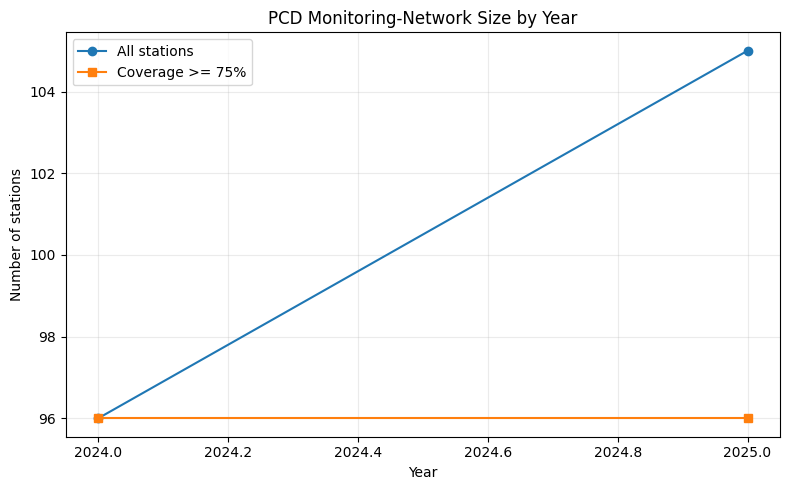

In [63]:
# CELL 14 — Annual monitoring-network size

fig, ax = plt.subplots(
    figsize=(
        8,
        5,
    )
)

ax.plot(
    coverage_summary_by_year[
        "year"
    ],
    coverage_summary_by_year[
        "station_n"
    ],
    marker="o",
    label="All stations",
)

ax.plot(
    coverage_summary_by_year[
        "year"
    ],
    coverage_summary_by_year[
        "eligible_station_n"
    ],
    marker="s",
    label=(
        f"Coverage >= "
        f"{MIN_ANNUAL_COVERAGE_PCT:.0f}%"
    ),
)

ax.set_xlabel(
    "Year"
)

ax.set_ylabel(
    "Number of stations"
)

ax.set_title(
    "PCD Monitoring-Network Size by Year"
)

ax.grid(
    alpha=0.25
)

ax.legend()

fig.tight_layout()

NETWORK_SIZE_FIG = (
    FIGURE_DIR
    / "05_monitoring_network_size_by_year.png"
)

fig.savefig(
    NETWORK_SIZE_FIG,
    dpi=250,
    bbox_inches="tight",
)

plt.show()

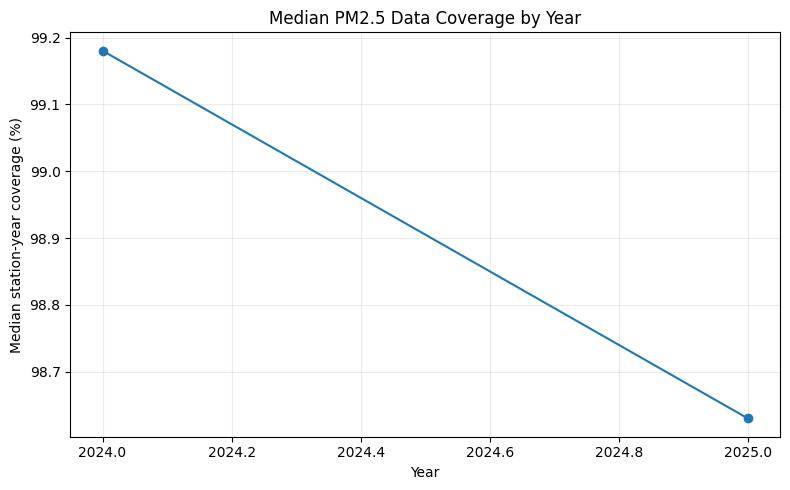

In [64]:
# CELL 15 — Median station completeness by year

fig, ax = plt.subplots(
    figsize=(
        8,
        5,
    )
)

ax.plot(
    coverage_summary_by_year[
        "year"
    ],
    coverage_summary_by_year[
        "median_coverage_pct"
    ],
    marker="o",
)

ax.set_xlabel(
    "Year"
)

ax.set_ylabel(
    "Median station-year coverage (%)"
)

ax.set_title(
    "Median PM2.5 Data Coverage by Year"
)

ax.grid(
    alpha=0.25
)

fig.tight_layout()

COVERAGE_FIG = (
    FIGURE_DIR
    / "05_median_station_coverage_by_year.png"
)

fig.savefig(
    COVERAGE_FIG,
    dpi=250,
    bbox_inches="tight",
)

plt.show()

# 5.8 Annual PM₂.₅ Variation

เราจะคำนวณ 2 แบบ:

## A. All available station-days

ใช้ข้อมูลทั้งหมดที่ basic QC ผ่านจาก Notebook 02

## B. Coverage-eligible station-years

ใช้เฉพาะ station-year ที่:

```text
calendar_year_coverage_pct >= 75%
```

การเปรียบเทียบสองแบบช่วยให้เห็น sensitivity ต่อ data completeness

In [65]:
# CELL 16 — Annual PM2.5 summaries

annual_all = (
    pm25_spatiotemporal
    .groupby(
        "year"
    )
    .agg(
        station_n=(
            "station_id",
            "nunique",
        ),

        station_day_n=(
            "pm25_mean",
            "count",
        ),

        mean_pm25=(
            "pm25_mean",
            "mean",
        ),

        median_pm25=(
            "pm25_mean",
            "median",
        ),

        q25_pm25=(
            "pm25_mean",
            lambda x:
                x.quantile(
                    0.25
                ),
        ),

        q75_pm25=(
            "pm25_mean",
            lambda x:
                x.quantile(
                    0.75
                ),
        ),
    )
    .reset_index()
)


eligible_station_year_keys = (
    station_year_coverage[
        station_year_coverage[
            "annual_coverage_eligible"
        ]
    ][
        [
            "station_id",
            "year",
        ]
    ]
    .drop_duplicates()
)


eligible_daily = (
    pm25_spatiotemporal
    .merge(
        eligible_station_year_keys.assign(
            _eligible=True
        ),
        on=[
            "station_id",
            "year",
        ],
        how="inner",
        validate="many_to_one",
    )
)


annual_eligible = (
    eligible_daily
    .groupby(
        "year"
    )
    .agg(
        station_n=(
            "station_id",
            "nunique",
        ),

        station_day_n=(
            "pm25_mean",
            "count",
        ),

        mean_pm25=(
            "pm25_mean",
            "mean",
        ),

        median_pm25=(
            "pm25_mean",
            "median",
        ),
    )
    .reset_index()
)


display(
    annual_all
)

display(
    annual_eligible
)

,year,station_n,station_day_n,mean_pm25,median_pm25,q25_pm25,q75_pm25
0,2024,96,34420,23.569134,18.6,11.8,30.0
1,2025,105,35753,21.033407,16.0,10.3,26.5


,year,station_n,station_day_n,mean_pm25,median_pm25
0,2024,96,34420,23.569134,18.6
1,2025,96,34096,21.379748,16.3


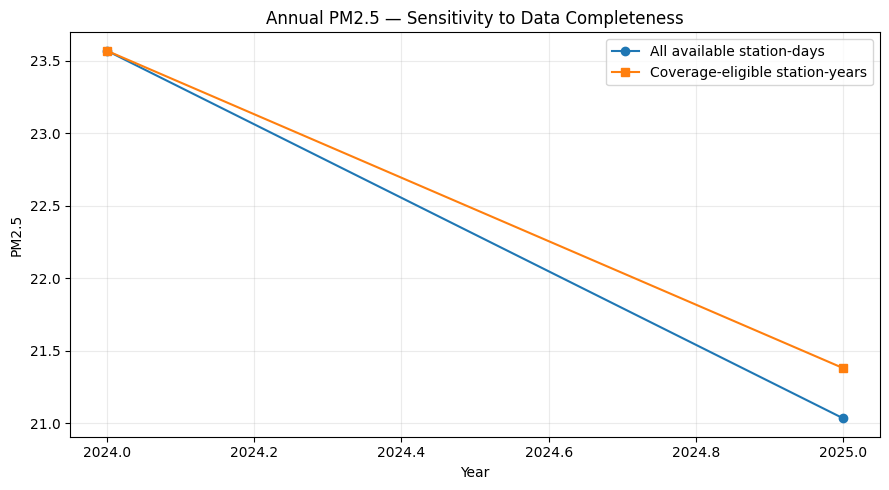

In [66]:
# CELL 17 — Plot annual all-data vs coverage-eligible means

annual_comparison = (
    annual_all[
        [
            "year",
            "mean_pm25",
            "median_pm25",
        ]
    ]
    .rename(
        columns={
            "mean_pm25":
                "mean_all",

            "median_pm25":
                "median_all",
        }
    )
    .merge(
        annual_eligible[
            [
                "year",
                "mean_pm25",
                "median_pm25",
            ]
        ]
        .rename(
            columns={
                "mean_pm25":
                    "mean_eligible",

                "median_pm25":
                    "median_eligible",
            }
        ),
        on="year",
        how="left",
    )
)


fig, ax = plt.subplots(
    figsize=(
        9,
        5,
    )
)

ax.plot(
    annual_comparison[
        "year"
    ],
    annual_comparison[
        "mean_all"
    ],
    marker="o",
    label="All available station-days",
)

ax.plot(
    annual_comparison[
        "year"
    ],
    annual_comparison[
        "mean_eligible"
    ],
    marker="s",
    label="Coverage-eligible station-years",
)

ax.set_xlabel(
    "Year"
)

ax.set_ylabel(
    "PM2.5"
)

ax.set_title(
    "Annual PM2.5 — Sensitivity to Data Completeness"
)

ax.grid(
    alpha=0.25
)

ax.legend()

fig.tight_layout()

ANNUAL_COMPARISON_FIG = (
    FIGURE_DIR
    / "05_annual_PM25_completeness_sensitivity.png"
)

fig.savefig(
    ANNUAL_COMPARISON_FIG,
    dpi=250,
    bbox_inches="tight",
)

plt.show()

# Interpretation

ถ้า:

```text
mean_all
≈
mean_eligible
```

ผล annual summary ค่อนข้าง insensitive ต่อ completeness filter

แต่ถ้าต่างกันมาก:

> annual comparison อาจขึ้นกับ station availability มาก

นี่เป็นเหตุผลที่ไม่ควร plot annual mean โดยไม่รายงาน network structure

# 5.9 Annual Maps with One Common Scale

สำหรับ annual station maps เราจะใช้:

```text
station-year mean PM2.5
```

และใช้ scale เดียวกันทุกปี

---

## Common map scale

กำหนด:

```text
vmin = 0
vmax = ceiling(max station-year mean / 10) × 10
```

ดังนั้นค่าทุกปีอยู่ใน scale เดียวกันและไม่มี clipping จาก robust percentile

นี่ช่วยให้เปรียบเทียบสีข้ามปีได้ตรงกว่า auto-scaling

In [67]:
# CELL 18 — Common annual map scale

annual_map_data = (
    station_year_pm25_gdf[
        station_year_pm25_gdf[
            "annual_coverage_eligible"
        ]
        &
        station_year_pm25_gdf[
            "mean_pm25"
        ].notna()
    ]
    .copy()
)


if len(
    annual_map_data
) == 0:

    raise RuntimeError(
        "No station-year records meet the annual "
        "coverage criterion."
    )


MAP_VMIN = 0.0

MAP_VMAX = (
    np.ceil(
        annual_map_data[
            "mean_pm25"
        ]
        .max()
        / 10
    )
    * 10
)


if (
    not np.isfinite(
        MAP_VMAX
    )
    or MAP_VMAX
    <= MAP_VMIN
):

    MAP_VMAX = 10.0


print(
    "Common annual PM2.5 map scale:"
)

print(
    "vmin =",
    MAP_VMIN
)

print(
    "vmax =",
    MAP_VMAX
)

Common annual PM2.5 map scale:
vmin = 0.0
vmax = 40.0


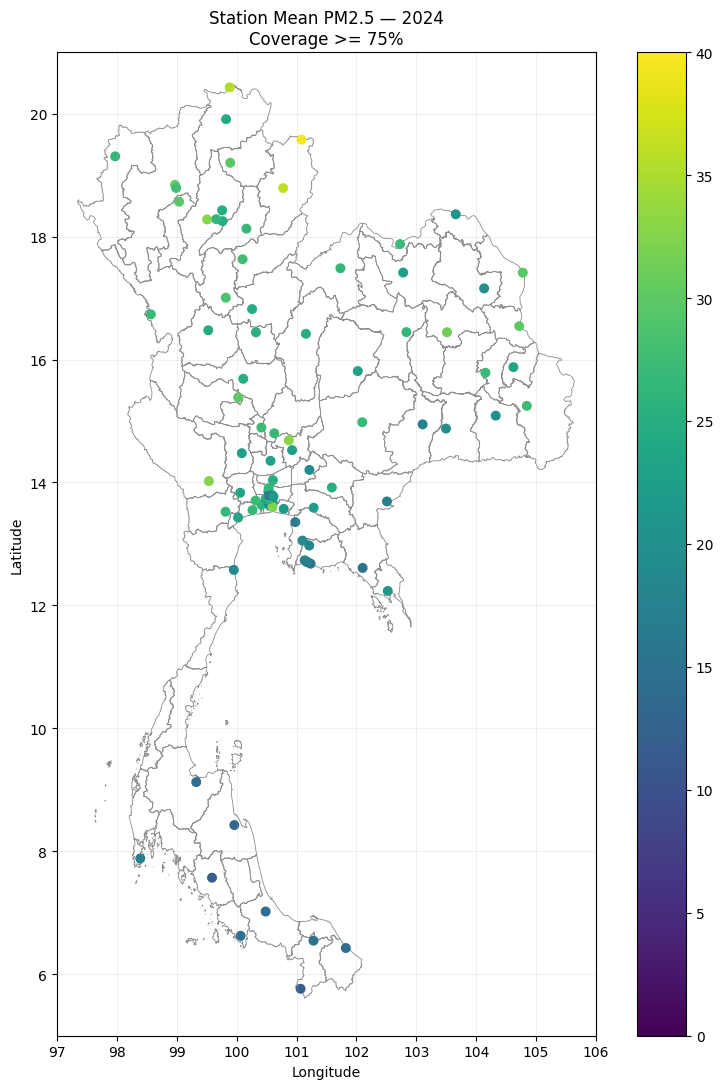

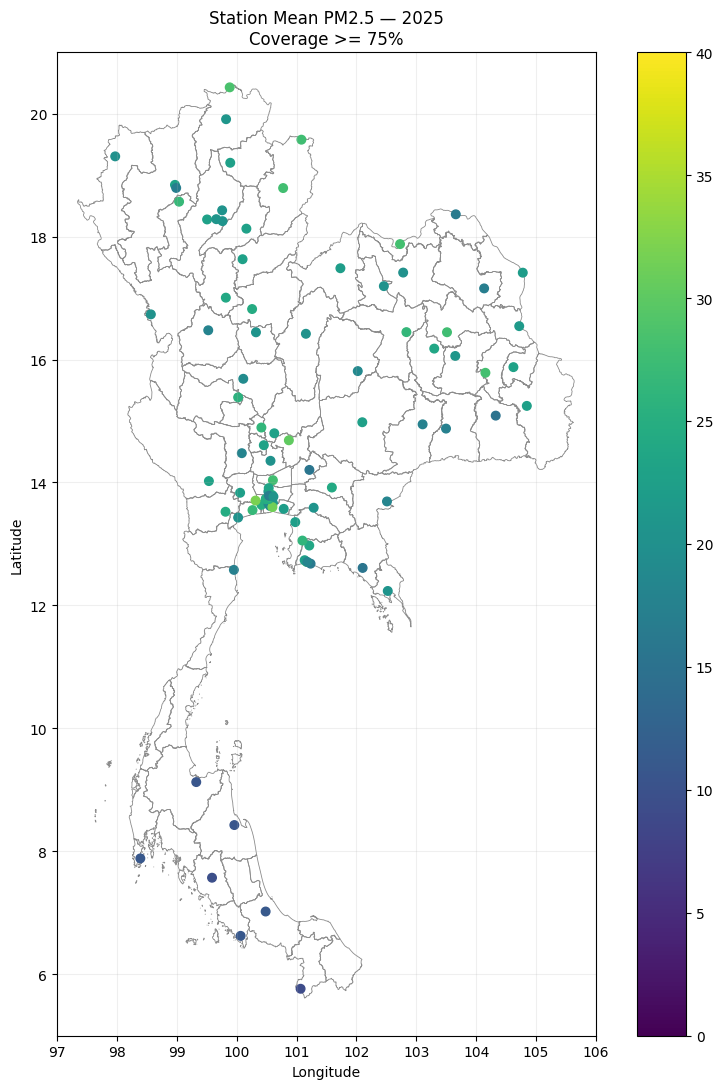

,year,station_n,vmin,vmax,figure
0,2024,96,0.0,40.0,/content/drive/MyDrive/Teaching_PCD_Environmen...
1,2025,96,0.0,40.0,/content/drive/MyDrive/Teaching_PCD_Environmen...


In [19]:
# CELL 19 — Annual station maps using the SAME scale

ANNUAL_MAP_YEARS = sorted(
    annual_map_data[
        "year"
    ]
    .dropna()
    .astype(int)
    .unique()
)


annual_map_inventory_rows = []


for year in ANNUAL_MAP_YEARS:

    map_year = (
        annual_map_data[
            annual_map_data[
                "year"
            ].eq(
                year
            )
        ]
        .copy()
    )


    fig, ax = plt.subplots(
        figsize=(
            8.5,
            11,
        )
    )

    province.plot(
        ax=ax,
        facecolor="none",
        edgecolor="0.55",
        linewidth=0.6,
    )

    map_year.plot(
        ax=ax,
        column="mean_pm25",
        legend=True,
        markersize=38,
        vmin=MAP_VMIN,
        vmax=MAP_VMAX,
    )

    ax.set_xlim(
        97,
        106,
    )

    ax.set_ylim(
        5,
        21,
    )

    ax.set_xlabel(
        "Longitude"
    )

    ax.set_ylabel(
        "Latitude"
    )

    ax.set_title(
        (
            f"Station Mean PM2.5 — {year}\n"
            f"Coverage >= {MIN_ANNUAL_COVERAGE_PCT:.0f}%"
        )
    )

    ax.grid(
        alpha=0.2
    )

    fig.tight_layout()

    map_path = (
        FIGURE_DIR
        / (
            f"05_PM25_annual_map_{year}.png"
        )
    )

    fig.savefig(
        map_path,
        dpi=250,
        bbox_inches="tight",
    )

    plt.show()


    annual_map_inventory_rows.append({
        "year":
            year,

        "station_n":
            len(
                map_year
            ),

        "vmin":
            MAP_VMIN,

        "vmax":
            MAP_VMAX,

        "figure":
            str(
                map_path
            ),
    })


annual_map_inventory = pd.DataFrame(
    annual_map_inventory_rows
)


display(
    annual_map_inventory
)

# Checkpoint — Honest Map Comparison

ตรวจว่า:

```text
vmin
vmax
```

เหมือนกันทุกปี

ถ้าเหมือนกัน:

> สีเดียวกันมีความหมายเชิงตัวเลขเดียวกันทุก annual map

นี่เป็นหลักสำคัญของ comparative cartography

# 5.10 Data-Availability Maps

ก่อนตีความ pollutant map ควรดู coverage map

เพราะ station ที่:

```text
mean PM2.5 = 35
coverage = 95%
```

กับ station ที่:

```text
mean PM2.5 = 35
coverage = 20%
```

ไม่ได้มีฐานข้อมูลสนับสนุนเท่ากัน

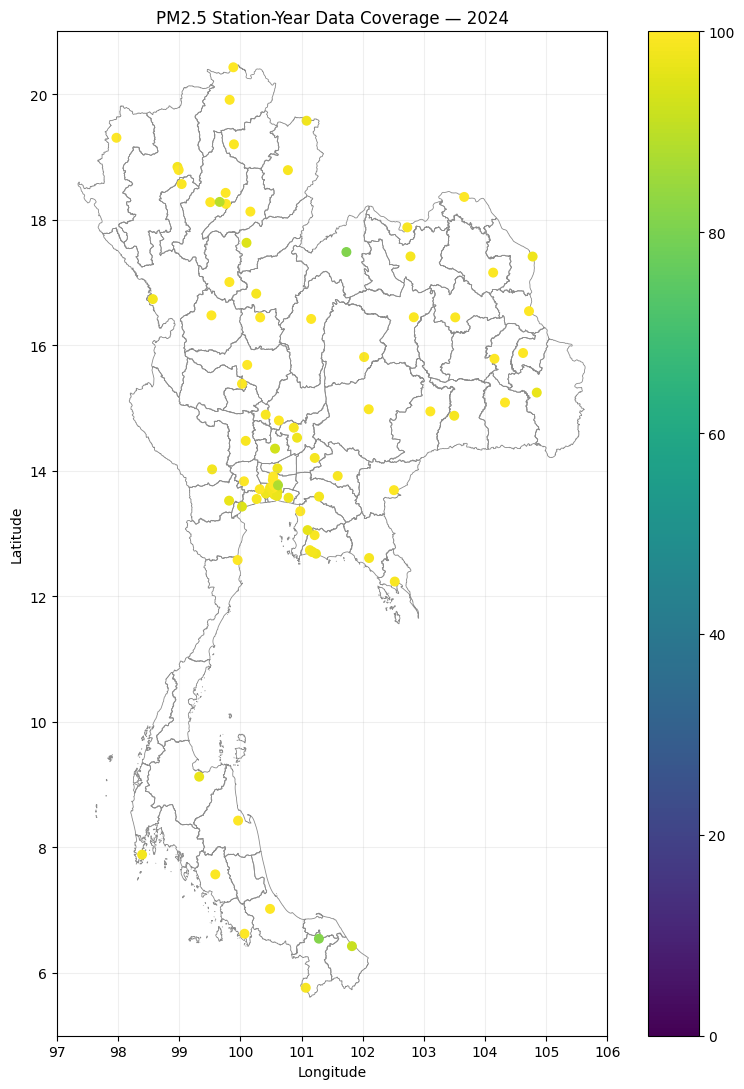

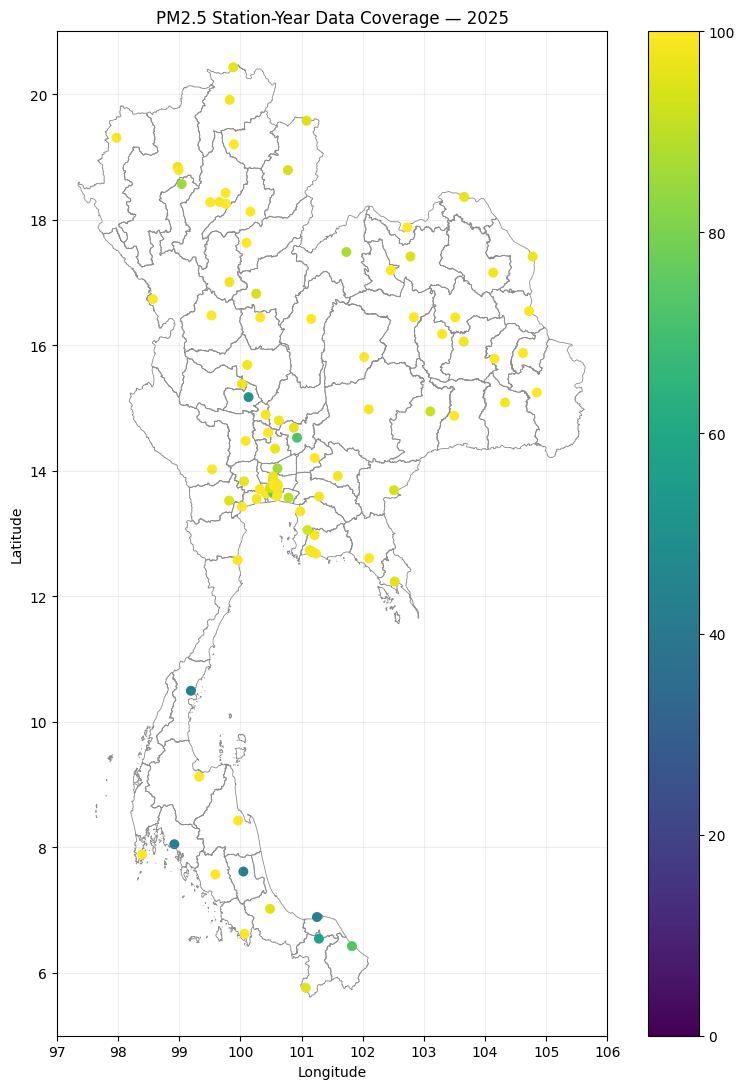

In [20]:
# CELL 20 — Annual coverage maps

for year in ANNUAL_MAP_YEARS:

    coverage_year = (
        station_year_pm25_gdf[
            station_year_pm25_gdf[
                "year"
            ].eq(
                year
            )
        ]
        .copy()
    )


    fig, ax = plt.subplots(
        figsize=(
            8.5,
            11,
        )
    )

    province.plot(
        ax=ax,
        facecolor="none",
        edgecolor="0.55",
        linewidth=0.6,
    )

    coverage_year.plot(
        ax=ax,
        column="calendar_year_coverage_pct",
        legend=True,
        markersize=38,
        vmin=0,
        vmax=100,
    )

    ax.set_xlim(
        97,
        106,
    )

    ax.set_ylim(
        5,
        21,
    )

    ax.set_xlabel(
        "Longitude"
    )

    ax.set_ylabel(
        "Latitude"
    )

    ax.set_title(
        f"PM2.5 Station-Year Data Coverage — {year}"
    )

    ax.grid(
        alpha=0.2
    )

    fig.tight_layout()

    path = (
        FIGURE_DIR
        / (
            f"05_PM25_coverage_map_{year}.png"
        )
    )

    fig.savefig(
        path,
        dpi=250,
        bbox_inches="tight",
    )

    plt.show()

# 5.11 Monthly Variation

รวม station-days ทุกปีใน teaching period แล้วดู distribution ตามเดือน

ต้องระวังว่า:

```text
January 2021–2025
```

เป็น pooled observations จากหลายปีและหลายสถานี

ดังนั้น boxplot นี้แสดง:

> distribution of available station-days

ไม่ใช่ climatological normal

In [21]:
# CELL 21 — Monthly PM2.5 descriptive statistics

monthly_pm25 = (
    pm25_spatiotemporal
    .groupby(
        "month"
    )
    .agg(
        station_n=(
            "station_id",
            "nunique",
        ),

        station_day_n=(
            "pm25_mean",
            "count",
        ),

        mean_pm25=(
            "pm25_mean",
            "mean",
        ),

        median_pm25=(
            "pm25_mean",
            "median",
        ),

        q25_pm25=(
            "pm25_mean",
            lambda x:
                x.quantile(
                    0.25
                ),
        ),

        q75_pm25=(
            "pm25_mean",
            lambda x:
                x.quantile(
                    0.75
                ),
        ),

        p90_pm25=(
            "pm25_mean",
            lambda x:
                x.quantile(
                    0.90
                ),
        ),
    )
    .reset_index()
)


monthly_pm25[
    "month_name"
] = (
    monthly_pm25[
        "month"
    ]
    .map(
        lambda m:
            calendar.month_abbr[
                int(
                    m
                )
            ]
    )
)


display(
    monthly_pm25
)

,month,station_n,station_day_n,mean_pm25,median_pm25,q25_pm25,q75_pm25,p90_pm25,month_name
0,1,100,6052,36.978866,34.75,25.10,46.4,58.50,Jan
1,2,100,5558,34.692911,32.30,21.90,44.7,57.00,Feb
2,3,100,6025,37.547900,30.60,20.90,46.9,68.26,Mar
3,4,100,5855,31.262408,25.10,16.50,39.6,58.30,Apr
4,5,100,5961,18.178410,14.90,10.10,22.1,32.70,May
5,6,100,5771,12.296898,11.40,8.55,15.0,19.10,Jun
6,7,101,5915,12.546847,11.80,9.00,15.2,19.30,Jul
7,8,105,6008,11.792344,11.10,8.40,14.3,17.90,Aug
8,9,105,5675,11.521692,10.30,7.70,14.1,18.50,Sep
9,10,104,5781,15.226916,13.60,9.60,19.1,25.70,Oct


/tmp/ipykernel_791/2067298414.py:30: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


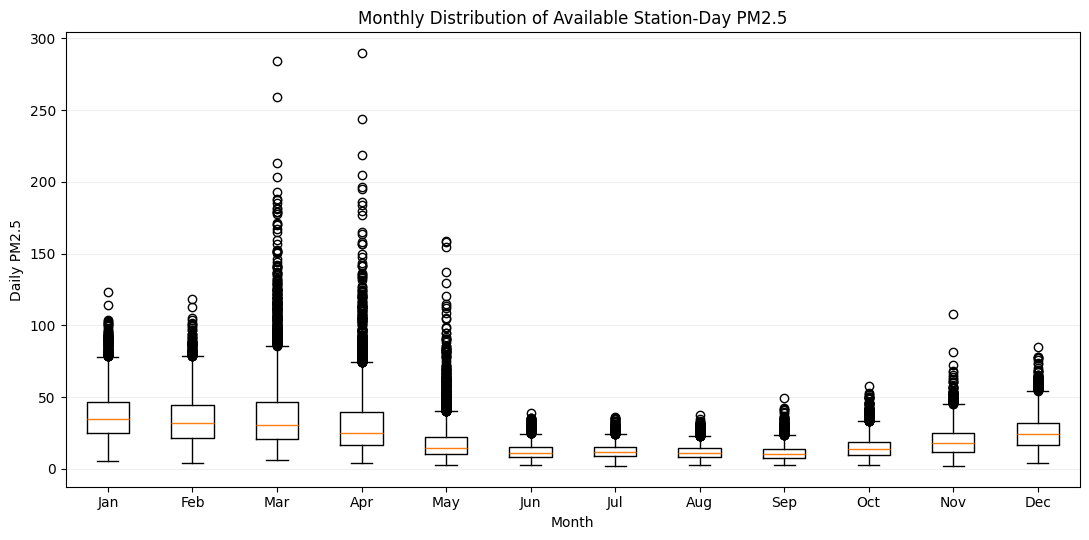

In [22]:
# CELL 22 — Monthly PM2.5 boxplot

monthly_groups = [
    pm25_spatiotemporal.loc[
        pm25_spatiotemporal[
            "month"
        ].eq(
            month
        ),
        "pm25_mean",
    ]
    .dropna()
    .values

    for month
    in range(
        1,
        13
    )
]


fig, ax = plt.subplots(
    figsize=(
        11,
        5.5,
    )
)

ax.boxplot(
    monthly_groups,
    labels=[
        calendar.month_abbr[
            month
        ]
        for month
        in range(
            1,
            13
        )
    ],
    showfliers=True,
)

ax.set_xlabel(
    "Month"
)

ax.set_ylabel(
    "Daily PM2.5"
)

ax.set_title(
    "Monthly Distribution of Available Station-Day PM2.5"
)

ax.grid(
    axis="y",
    alpha=0.2,
)

fig.tight_layout()

MONTHLY_FIG = (
    FIGURE_DIR
    / "05_PM25_monthly_distribution.png"
)

fig.savefig(
    MONTHLY_FIG,
    dpi=250,
    bbox_inches="tight",
)

plt.show()

# 5.12 Station-Month Completeness

Monthly analysis ก็ควรมี completeness

สำหรับแต่ละ:

```text
station × year × month
```

คำนวณ:

```text
observed_days
expected_days_in_month
monthly_coverage_pct
```

เช่น February อาจมี:

```text
28 หรือ 29 วัน
```

In [23]:
# CELL 23 — Station-month completeness

station_month_coverage = (
    pm25_spatiotemporal
    .groupby(
        [
            "station_id",
            "year",
            "month",
        ]
    )
    .agg(
        observed_days=(
            "date",
            "nunique",
        ),

        pm25_non_missing_days=(
            "pm25_mean",
            "count",
        ),
    )
    .reset_index()
)


station_month_coverage[
    "expected_days_in_month"
] = (
    station_month_coverage.apply(
        lambda row:
            calendar.monthrange(
                int(
                    row[
                        "year"
                    ]
                ),
                int(
                    row[
                        "month"
                    ]
                ),
            )[
                1
            ],
        axis=1,
    )
)


station_month_coverage[
    "monthly_coverage_pct"
] = (
    station_month_coverage[
        "pm25_non_missing_days"
    ]
    /
    station_month_coverage[
        "expected_days_in_month"
    ]
    * 100
)


display(
    station_month_coverage.head(
        20
    )
)

,station_id,year,month,observed_days,pm25_non_missing_days,expected_days_in_month,monthly_coverage_pct
0,02t,2024,1,31,31,31,100.000000
1,02t,2024,2,29,29,29,100.000000
2,02t,2024,3,31,31,31,100.000000
3,02t,2024,4,30,30,30,100.000000
4,02t,2024,5,31,31,31,100.000000
5,02t,2024,6,30,30,30,100.000000
6,02t,2024,7,31,31,31,100.000000
7,02t,2024,8,31,31,31,100.000000
8,02t,2024,9,30,30,30,100.000000
9,02t,2024,10,31,31,31,100.000000


# 5.13 Dry – Wet – May Transition

ใช้ classification:

```text
Dry (Nov-Apr)
Wet (Jun-Oct)
Transition (May)
```

เราจะวิเคราะห์แบบ descriptive ก่อน

ไม่ทำ statistical significance test ใน Notebook นี้
เพราะ spatial-temporal dependence และ unequal station coverage ต้องพิจารณาเพิ่มเติม

In [24]:
# CELL 24 — Seasonal PM2.5 summary

season_order = [
    "Dry (Nov-Apr)",
    "Transition (May)",
    "Wet (Jun-Oct)",
]


seasonal_pm25 = (
    pm25_spatiotemporal
    .groupby(
        "season_teaching",
        dropna=False,
    )
    .agg(
        station_n=(
            "station_id",
            "nunique",
        ),

        station_day_n=(
            "pm25_mean",
            "count",
        ),

        mean_pm25=(
            "pm25_mean",
            "mean",
        ),

        median_pm25=(
            "pm25_mean",
            "median",
        ),

        q25_pm25=(
            "pm25_mean",
            lambda x:
                x.quantile(
                    0.25
                ),
        ),

        q75_pm25=(
            "pm25_mean",
            lambda x:
                x.quantile(
                    0.75
                ),
        ),

        p90_pm25=(
            "pm25_mean",
            lambda x:
                x.quantile(
                    0.90
                ),
        ),
    )
    .reset_index()
)


seasonal_pm25[
    "season_teaching"
] = pd.Categorical(
    seasonal_pm25[
        "season_teaching"
    ],
    categories=season_order,
    ordered=True,
)


seasonal_pm25 = (
    seasonal_pm25
    .sort_values(
        "season_teaching"
    )
    .reset_index(
        drop=True
    )
)


display(
    seasonal_pm25
)

,season_teaching,station_n,station_day_n,mean_pm25,median_pm25,q25_pm25,q75_pm25,p90_pm25
0,Dry (Nov-Apr),105,35062,30.958151,26.8,18.2,39.3,54.3
1,Transition (May),100,5961,18.178410,14.9,10.1,22.1,32.7
2,Wet (Jun-Oct),105,29150,12.673784,11.6,8.6,15.4,20.1


/tmp/ipykernel_791/2876242347.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


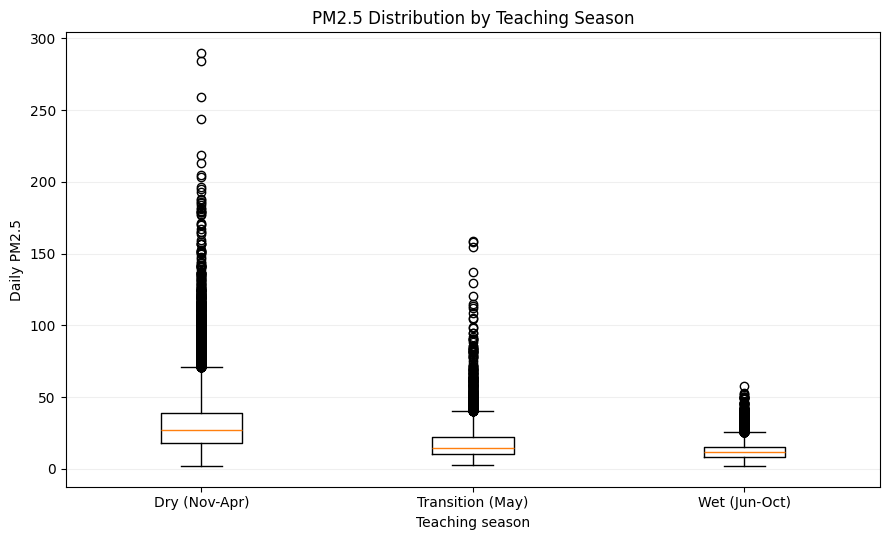

In [25]:
# CELL 25 — Seasonal distribution boxplot

season_groups = [
    pm25_spatiotemporal.loc[
        pm25_spatiotemporal[
            "season_teaching"
        ].eq(
            season
        ),
        "pm25_mean",
    ]
    .dropna()
    .values

    for season
    in season_order
]


fig, ax = plt.subplots(
    figsize=(
        9,
        5.5,
    )
)

ax.boxplot(
    season_groups,
    labels=season_order,
    showfliers=True,
)

ax.set_xlabel(
    "Teaching season"
)

ax.set_ylabel(
    "Daily PM2.5"
)

ax.set_title(
    "PM2.5 Distribution by Teaching Season"
)

ax.grid(
    axis="y",
    alpha=0.2,
)

fig.tight_layout()

SEASON_FIG = (
    FIGURE_DIR
    / "05_PM25_seasonal_distribution.png"
)

fig.savefig(
    SEASON_FIG,
    dpi=250,
    bbox_inches="tight",
)

plt.show()

In [26]:
# CELL 26 — Station-season summaries

station_season_pm25 = (
    pm25_spatiotemporal
    .groupby(
        [
            "station_id",
            "season_teaching",
        ],
        dropna=False,
    )
    .agg(
        station_day_n=(
            "pm25_mean",
            "count",
        ),

        mean_pm25=(
            "pm25_mean",
            "mean",
        ),

        median_pm25=(
            "pm25_mean",
            "median",
        ),

        p90_pm25=(
            "pm25_mean",
            lambda x:
                x.quantile(
                    0.90
                ),
        ),
    )
    .reset_index()
)


station_season_pm25 = (
    station_season_pm25
    .merge(
        pcd_stations[
            station_year_geometry_fields
        ],
        on="station_id",
        how="left",
        validate="many_to_one",
    )
)


station_season_pm25_gdf = (
    gpd.GeoDataFrame(
        station_season_pm25,
        geometry="geometry",
        crs=pcd_stations.crs,
    )
)


display(
    station_season_pm25_gdf.head(
        20
    )
)

,station_id,season_teaching,station_day_n,mean_pm25,median_pm25,p90_pm25,station_name_en,station_name_th,province_name_en,province_name_th,latitude,longitude,geometry
0,02t,Dry (Nov-Apr),361,32.332687,28.50,51.50,Bansomdejchaopraya Rajabhat University,มหาวิทยาลัยราชภัฏบ้านสมเด็จเจ้าพระยา,Bangkok,กรุงเทพมหานคร,13.732846,100.487662,POINT (100.48766 13.73285)
1,02t,Transition (May),60,19.536667,17.25,32.40,Bansomdejchaopraya Rajabhat University,มหาวิทยาลัยราชภัฏบ้านสมเด็จเจ้าพระยา,Bangkok,กรุงเทพมหานคร,13.732846,100.487662,POINT (100.48766 13.73285)
2,02t,Wet (Jun-Oct),306,15.497712,14.55,20.50,Bansomdejchaopraya Rajabhat University,มหาวิทยาลัยราชภัฏบ้านสมเด็จเจ้าพระยา,Bangkok,กรุงเทพมหานคร,13.732846,100.487662,POINT (100.48766 13.73285)
3,03t,Dry (Nov-Apr),361,32.739889,29.50,51.30,Highway NO.3902 km.13 +600,ริมถนนทางหลวงหมายเลข 3902,Bangkok,กรุงเทพมหานคร,13.636514,100.414262,POINT (100.41426 13.63651)
4,03t,Transition (May),60,21.198333,18.15,36.88,Highway NO.3902 km.13 +600,ริมถนนทางหลวงหมายเลข 3902,Bangkok,กรุงเทพมหานคร,13.636514,100.414262,POINT (100.41426 13.63651)
5,03t,Wet (Jun-Oct),296,17.327027,16.30,22.90,Highway NO.3902 km.13 +600,ริมถนนทางหลวงหมายเลข 3902,Bangkok,กรุงเทพมหานคร,13.636514,100.414262,POINT (100.41426 13.63651)
6,05t,Dry (Nov-Apr),351,29.110826,26.40,46.20,Thai Meteorological Department,กรมอุตุนิยมวิทยาบางนา,Bangkok,กรุงเทพมหานคร,13.666183,100.605742,POINT (100.60574 13.66618)
7,05t,Transition (May),62,18.270968,15.25,32.19,Thai Meteorological Department,กรมอุตุนิยมวิทยาบางนา,Bangkok,กรุงเทพมหานคร,13.666183,100.605742,POINT (100.60574 13.66618)
8,05t,Wet (Jun-Oct),295,15.043729,14.40,19.80,Thai Meteorological Department,กรมอุตุนิยมวิทยาบางนา,Bangkok,กรุงเทพมหานคร,13.666183,100.605742,POINT (100.60574 13.66618)
9,08t,Dry (Nov-Apr),360,33.008889,29.45,50.77,Prabadang Rehabiltation Center,ศูนย์ฟื้นฟูอาชีพคนพิการและทุพลภาพ,Samut Prakan,สมุทรปราการ,13.664087,100.543436,POINT (100.54344 13.66409)


# 5.14 Three-Province Case Study

ใช้:

```text
Saraburi
Lop Buri
Nakhon Nayok
```

เป็น case study ต่อเนื่อง

แต่จะใช้ province name แบบ normalized
เพื่อรองรับความแตกต่างเล็กน้อย เช่น:

```text
Lopburi
Lop Buri
```

In [27]:
# CELL 27 — Normalize province names

CASE_PROVINCE_MAP = {
    "saraburi":
        "Saraburi",

    "lop buri":
        "Lop Buri",

    "lopburi":
        "Lop Buri",

    "nakhon nayok":
        "Nakhon Nayok",

    "nakhonnayok":
        "Nakhon Nayok",
}


def normalize_place_name(
    value,
):
    if pd.isna(
        value
    ):
        return None

    return " ".join(
        str(
            value
        )
        .strip()
        .lower()
        .split()
    )


pm25_spatiotemporal[
    "province_normalized"
] = (
    pm25_spatiotemporal[
        "province_name_en"
    ]
    .map(
        normalize_place_name
    )
)


pm25_spatiotemporal[
    "case_province"
] = (
    pm25_spatiotemporal[
        "province_normalized"
    ]
    .map(
        CASE_PROVINCE_MAP
    )
)


case_daily = (
    pm25_spatiotemporal[
        pm25_spatiotemporal[
            "case_province"
        ]
        .notna()
    ]
    .copy()
)


print(
    "Case-study station-days:",
    len(
        case_daily
    )
)

print(
    "Case-study stations:",
    case_daily[
        "station_id"
    ].nunique()
)


display(
    case_daily[
        [
            "station_id",
            "case_province",
        ]
    ]
    .drop_duplicates()
    .sort_values(
        [
            "case_province",
            "station_id",
        ]
    )
)

Case-study station-days: 2780
Case-study stations: 4


,station_id,case_province
69450,99t,Lop Buri
6483,105t,Nakhon Nayok
22658,24t,Saraburi
23371,25t,Saraburi


In [28]:
# CELL 28 — Three-province annual summary

case_annual_summary = (
    case_daily
    .groupby(
        [
            "case_province",
            "year",
        ]
    )
    .agg(
        station_n=(
            "station_id",
            "nunique",
        ),

        station_day_n=(
            "pm25_mean",
            "count",
        ),

        mean_pm25=(
            "pm25_mean",
            "mean",
        ),

        median_pm25=(
            "pm25_mean",
            "median",
        ),

        p90_pm25=(
            "pm25_mean",
            lambda x:
                x.quantile(
                    0.90
                ),
        ),
    )
    .reset_index()
)


display(
    case_annual_summary
)

,case_province,year,station_n,station_day_n,mean_pm25,median_pm25,p90_pm25
0,Lop Buri,2024,1,366,26.809290,24.35,46.50
1,Lop Buri,2025,1,357,22.777591,16.70,45.58
2,Nakhon Nayok,2024,1,361,19.305540,16.90,31.50
3,Nakhon Nayok,2025,1,364,15.477747,12.40,29.10
4,Saraburi,2024,2,717,27.639609,24.90,45.50
5,Saraburi,2025,2,615,26.360976,21.90,46.88


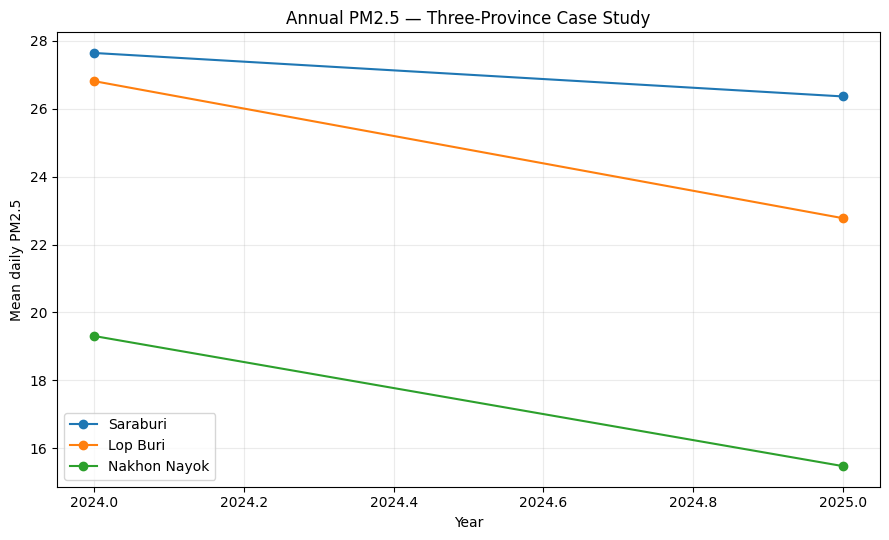

In [29]:
# CELL 29 — Annual PM2.5 lines for the three provinces

fig, ax = plt.subplots(
    figsize=(
        9,
        5.5,
    )
)


for province_name in [
    "Saraburi",
    "Lop Buri",
    "Nakhon Nayok",
]:

    subset = (
        case_annual_summary[
            case_annual_summary[
                "case_province"
            ].eq(
                province_name
            )
        ]
        .sort_values(
            "year"
        )
    )

    if len(
        subset
    ) == 0:
        continue

    ax.plot(
        subset[
            "year"
        ],
        subset[
            "mean_pm25"
        ],
        marker="o",
        label=province_name,
    )


ax.set_xlabel(
    "Year"
)

ax.set_ylabel(
    "Mean daily PM2.5"
)

ax.set_title(
    "Annual PM2.5 — Three-Province Case Study"
)

ax.grid(
    alpha=0.25
)

ax.legend()

fig.tight_layout()

CASE_ANNUAL_FIG = (
    FIGURE_DIR
    / "05_case_three_provinces_annual_PM25.png"
)

fig.savefig(
    CASE_ANNUAL_FIG,
    dpi=250,
    bbox_inches="tight",
)

plt.show()

In [30]:
# CELL 30 — Three-province monthly summary

case_monthly_summary = (
    case_daily
    .groupby(
        [
            "case_province",
            "month",
        ]
    )
    .agg(
        station_n=(
            "station_id",
            "nunique",
        ),

        station_day_n=(
            "pm25_mean",
            "count",
        ),

        mean_pm25=(
            "pm25_mean",
            "mean",
        ),

        median_pm25=(
            "pm25_mean",
            "median",
        ),
    )
    .reset_index()
)


display(
    case_monthly_summary
)

,case_province,month,station_n,station_day_n,mean_pm25,median_pm25
0,Lop Buri,1,1,62,44.800000,43.25
1,Lop Buri,2,1,57,42.061404,41.40
2,Lop Buri,3,1,62,39.101613,37.30
3,Lop Buri,4,1,60,35.720000,32.75
4,Lop Buri,5,1,62,19.795161,16.95
5,Lop Buri,6,1,60,13.196667,13.15
6,Lop Buri,7,1,62,13.680645,13.30
7,Lop Buri,8,1,62,14.054839,13.80
8,Lop Buri,9,1,60,12.555000,12.75
9,Lop Buri,10,1,62,17.469355,15.70


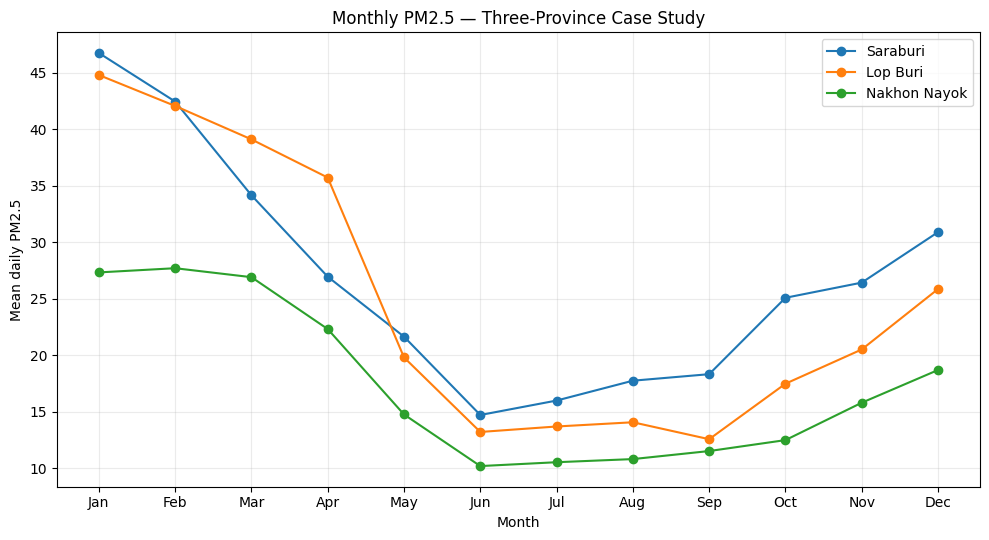

In [31]:
# CELL 31 — Monthly lines for the three provinces

fig, ax = plt.subplots(
    figsize=(
        10,
        5.5,
    )
)


for province_name in [
    "Saraburi",
    "Lop Buri",
    "Nakhon Nayok",
]:

    subset = (
        case_monthly_summary[
            case_monthly_summary[
                "case_province"
            ].eq(
                province_name
            )
        ]
        .sort_values(
            "month"
        )
    )

    if len(
        subset
    ) == 0:
        continue

    ax.plot(
        subset[
            "month"
        ],
        subset[
            "mean_pm25"
        ],
        marker="o",
        label=province_name,
    )


ax.set_xticks(
    range(
        1,
        13
    )
)

ax.set_xticklabels(
    [
        calendar.month_abbr[
            m
        ]
        for m
        in range(
            1,
            13
        )
    ]
)

ax.set_xlabel(
    "Month"
)

ax.set_ylabel(
    "Mean daily PM2.5"
)

ax.set_title(
    "Monthly PM2.5 — Three-Province Case Study"
)

ax.grid(
    alpha=0.25
)

ax.legend()

fig.tight_layout()

CASE_MONTHLY_FIG = (
    FIGURE_DIR
    / "05_case_three_provinces_monthly_PM25.png"
)

fig.savefig(
    CASE_MONTHLY_FIG,
    dpi=250,
    bbox_inches="tight",
)

plt.show()

In [32]:
# CELL 32 — Three-province seasonal summary

case_seasonal_summary = (
    case_daily
    .groupby(
        [
            "case_province",
            "season_teaching",
        ]
    )
    .agg(
        station_n=(
            "station_id",
            "nunique",
        ),

        station_day_n=(
            "pm25_mean",
            "count",
        ),

        mean_pm25=(
            "pm25_mean",
            "mean",
        ),

        median_pm25=(
            "pm25_mean",
            "median",
        ),

        p90_pm25=(
            "pm25_mean",
            lambda x:
                x.quantile(
                    0.90
                ),
        ),
    )
    .reset_index()
)


display(
    case_seasonal_summary
)

,case_province,season_teaching,station_n,station_day_n,mean_pm25,median_pm25,p90_pm25
0,Lop Buri,Dry (Nov-Apr),1,355,34.841408,32.50,54.70
1,Lop Buri,Transition (May),1,62,19.795161,16.95,36.67
2,Lop Buri,Wet (Jun-Oct),1,306,14.208497,13.45,20.25
3,Nakhon Nayok,Dry (Nov-Apr),1,360,23.126389,21.85,34.31
4,Nakhon Nayok,Transition (May),1,62,14.745161,13.10,26.61
5,Nakhon Nayok,Wet (Jun-Oct),1,303,11.100660,10.80,15.66
6,Saraburi,Dry (Nov-Apr),2,676,35.100148,31.40,55.80
7,Saraburi,Transition (May),2,120,21.632500,20.30,36.23
8,Saraburi,Wet (Jun-Oct),2,536,18.108209,17.00,27.60


# 5.15 Map the Three-Province Case Study

เราจะใช้ station-year means เช่นเดียวกับ national annual maps
แต่ zoom เข้าพื้นที่ 3 จังหวัด

จุดประสงค์:

- อ่าน station distribution
- เปรียบเทียบจังหวัด
- เห็นพื้นที่ที่ station sparse
- เตรียมสำหรับ spatial statistics

ยังไม่ทำ interpolation

In [33]:
# CELL 33 — Case province polygons and station-year map data

province[
    "_name_norm"
] = (
    province[
        "province_name_en"
    ]
    .map(
        normalize_place_name
    )
)


case_provinces = (
    province[
        province[
            "_name_norm"
        ]
        .isin(
            CASE_PROVINCE_MAP.keys()
        )
    ]
    .copy()
)


station_year_pm25_gdf[
    "province_normalized"
] = (
    station_year_pm25_gdf[
        "province_name_en"
    ]
    .map(
        normalize_place_name
    )
)


case_station_year = (
    station_year_pm25_gdf[
        station_year_pm25_gdf[
            "province_normalized"
        ]
        .isin(
            CASE_PROVINCE_MAP.keys()
        )
    ]
    .copy()
)


print(
    "Case province polygons:",
    len(
        case_provinces
    )
)

print(
    "Case station-year records:",
    len(
        case_station_year
    )
)

Case province polygons: 3
Case station-year records: 8


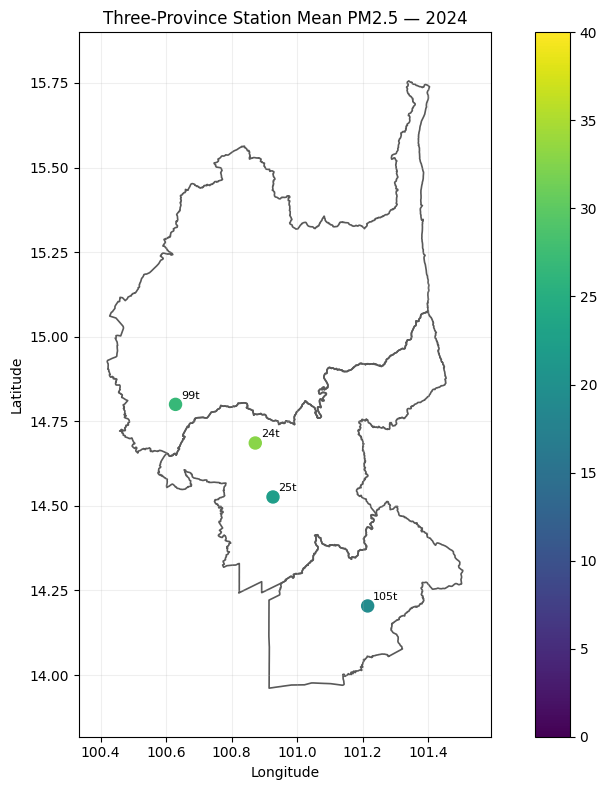

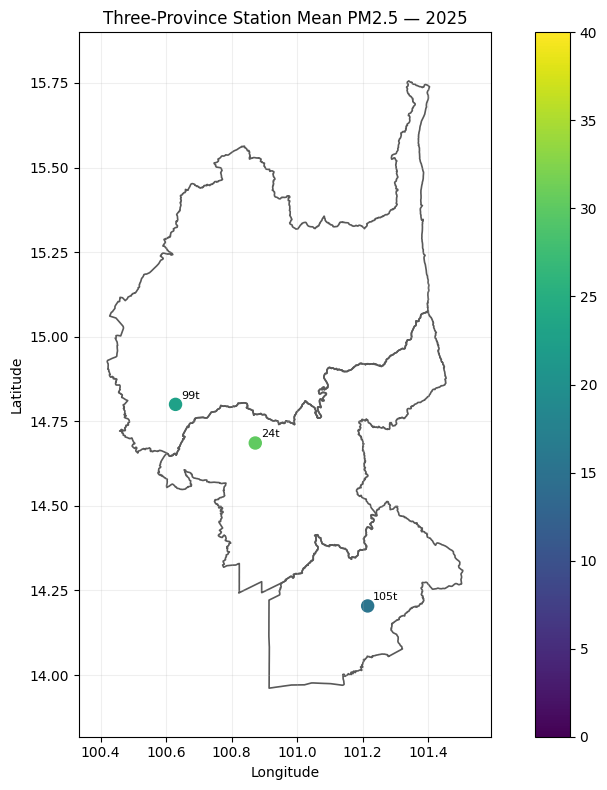

In [34]:
# CELL 34 — Case annual maps with the same national scale

for year in sorted(
    case_station_year[
        "year"
    ]
    .dropna()
    .astype(int)
    .unique()
):

    map_year = (
        case_station_year[
            case_station_year[
                "year"
            ].eq(
                year
            )
            &
            case_station_year[
                "annual_coverage_eligible"
            ]
        ]
        .copy()
    )


    if len(
        map_year
    ) == 0:

        continue


    fig, ax = plt.subplots(
        figsize=(
            9,
            8,
        )
    )

    case_provinces.plot(
        ax=ax,
        facecolor="none",
        edgecolor="0.35",
        linewidth=1.2,
    )

    map_year.plot(
        ax=ax,
        column="mean_pm25",
        legend=True,
        markersize=75,
        vmin=MAP_VMIN,
        vmax=MAP_VMAX,
    )


    for _, row in map_year.iterrows():

        ax.annotate(
            str(
                row[
                    "station_id"
                ]
            ),
            xy=(
                row.geometry.x,
                row.geometry.y,
            ),
            xytext=(
                4,
                4,
            ),
            textcoords="offset points",
            fontsize=8,
        )


    xmin, ymin, xmax, ymax = (
        case_provinces.total_bounds
    )

    xpad = (
        xmax
        - xmin
    ) * 0.08

    ypad = (
        ymax
        - ymin
    ) * 0.08


    ax.set_xlim(
        xmin - xpad,
        xmax + xpad,
    )

    ax.set_ylim(
        ymin - ypad,
        ymax + ypad,
    )

    ax.set_xlabel(
        "Longitude"
    )

    ax.set_ylabel(
        "Latitude"
    )

    ax.set_title(
        f"Three-Province Station Mean PM2.5 — {year}"
    )

    ax.grid(
        alpha=0.2
    )

    fig.tight_layout()

    path = (
        FIGURE_DIR
        / (
            f"05_case_PM25_map_{year}.png"
        )
    )

    fig.savefig(
        path,
        dpi=250,
        bbox_inches="tight",
    )

    plt.show()

# 5.16 Network-Daily PM₂.₅

เพื่อหา “high-PM₂.₅ episode” แบบ exploratory
เราจะสร้าง daily network summary:

```text
date
station_n
network_mean_pm25
network_median_pm25
network_p90_pm25
```

ทำไมใช้ median เป็นหลัก?

เพราะ:

```text
network mean
```

อาจถูกดึงขึ้นด้วยสถานี extreme เพียงไม่กี่แห่ง

median ช่วยแสดง central condition ของ available monitoring network ในวันนั้น

แต่ยังขึ้นกับ station availability อยู่

In [35]:
# CELL 35 — Daily network summary

network_daily = (
    pm25_spatiotemporal
    .groupby(
        "date"
    )
    .agg(
        station_n=(
            "station_id",
            "nunique",
        ),

        network_mean_pm25=(
            "pm25_mean",
            "mean",
        ),

        network_median_pm25=(
            "pm25_mean",
            "median",
        ),

        network_p90_pm25=(
            "pm25_mean",
            lambda x:
                x.quantile(
                    0.90
                ),
        ),

        network_max_pm25=(
            "pm25_mean",
            "max",
        ),
    )
    .reset_index()
)


display(
    network_daily.head(
        10
    )
)

,date,station_n,network_mean_pm25,network_median_pm25,network_p90_pm25,network_max_pm25
0,2024-01-01,95,25.330526,24.70,35.16,52.0
1,2024-01-02,95,24.578947,24.60,35.08,44.8
2,2024-01-03,95,25.437895,25.00,37.08,56.8
3,2024-01-04,95,25.416842,25.80,37.14,55.3
4,2024-01-05,95,27.944211,26.30,38.22,57.8
5,2024-01-06,95,30.852632,31.00,41.40,67.8
6,2024-01-07,95,32.509474,33.40,45.96,73.8
7,2024-01-08,95,35.346316,35.90,49.78,68.5
8,2024-01-09,96,42.119792,39.75,63.45,83.8
9,2024-01-10,95,38.177895,36.80,55.08,78.2


# 5.17 Define High-PM₂.₅ Episode Dates

จะไม่ใช้คำว่า:

```text
regulatory exceedance
```

เพราะ Notebook นี้ไม่ได้กำลังประเมินมาตรฐานกฎหมาย

เราจะนิยาม teaching high episode เป็น:

```text
network median PM2.5
>= 95th percentile
```

แต่เฉพาะวันที่มีจำนวนสถานีไม่น้อยเกินไป

กำหนด:

```text
MIN_STATIONS_FOR_NETWORK_DAY
=
max(5, 25th percentile of daily station count)
```

เพื่อหลีกเลี่ยงวันที่มี station เพียงไม่กี่แห่ง

In [36]:
# CELL 36 — High-episode parameter definition

daily_station_count_q25 = (
    network_daily[
        "station_n"
    ]
    .quantile(
        0.25
    )
)


MIN_STATIONS_FOR_NETWORK_DAY = max(
    5,
    int(
        np.floor(
            daily_station_count_q25
        )
    ),
)


network_daily_valid = (
    network_daily[
        network_daily[
            "station_n"
        ]
        >= MIN_STATIONS_FOR_NETWORK_DAY
    ]
    .copy()
)


HIGH_EPISODE_PERCENTILE = 0.95


HIGH_EPISODE_THRESHOLD = (
    network_daily_valid[
        "network_median_pm25"
    ]
    .quantile(
        HIGH_EPISODE_PERCENTILE
    )
)


network_daily_valid[
    "high_episode_flag"
] = (
    network_daily_valid[
        "network_median_pm25"
    ]
    >= HIGH_EPISODE_THRESHOLD
)


high_episode_dates = (
    network_daily_valid[
        network_daily_valid[
            "high_episode_flag"
        ]
    ]
    .sort_values(
        [
            "network_median_pm25",
            "date",
        ],
        ascending=[
            False,
            True,
        ],
    )
    .reset_index(
        drop=True
    )
)


print(
    "Minimum stations per network day:",
    MIN_STATIONS_FOR_NETWORK_DAY
)

print(
    "95th-percentile network-median threshold:",
    HIGH_EPISODE_THRESHOLD
)

print(
    "High-episode dates:",
    len(
        high_episode_dates
    )
)


display(
    high_episode_dates.head(
        20
    )
)

Minimum stations per network day: 95
95th-percentile network-median threshold: 43.614999999999995
High-episode dates: 28


,date,station_n,network_mean_pm25,network_median_pm25,network_p90_pm25,network_max_pm25,high_episode_flag
0,2025-03-23,99,67.793939,68.50,94.00,129.6,True
1,2025-03-24,99,67.831313,65.30,93.86,135.0,True
2,2025-01-24,98,62.385714,63.85,90.99,123.0,True
3,2025-01-23,100,62.232000,60.70,89.74,114.5,True
4,2024-02-14,96,58.222917,59.60,81.30,113.1,True
5,2025-01-25,99,57.163636,58.50,85.94,100.8,True
6,2025-01-22,97,56.617526,56.60,79.08,95.3,True
7,2024-02-15,96,54.218750,54.65,79.05,118.7,True
8,2025-03-22,100,56.789000,54.35,85.32,104.4,True
9,2025-03-25,98,60.820408,54.15,90.70,129.2,True


# Important

`HIGH_EPISODE_THRESHOLD` เป็น:

> data-derived percentile threshold

ไม่ใช่:

- AQI category
- Thai ambient air-quality standard
- health-risk threshold
- legal exceedance criterion

หากจะวิเคราะห์มาตรฐาน ต้องเพิ่ม:

```text
official standard
averaging period
effective date
regulatory definition
```

อย่างถูกต้อง

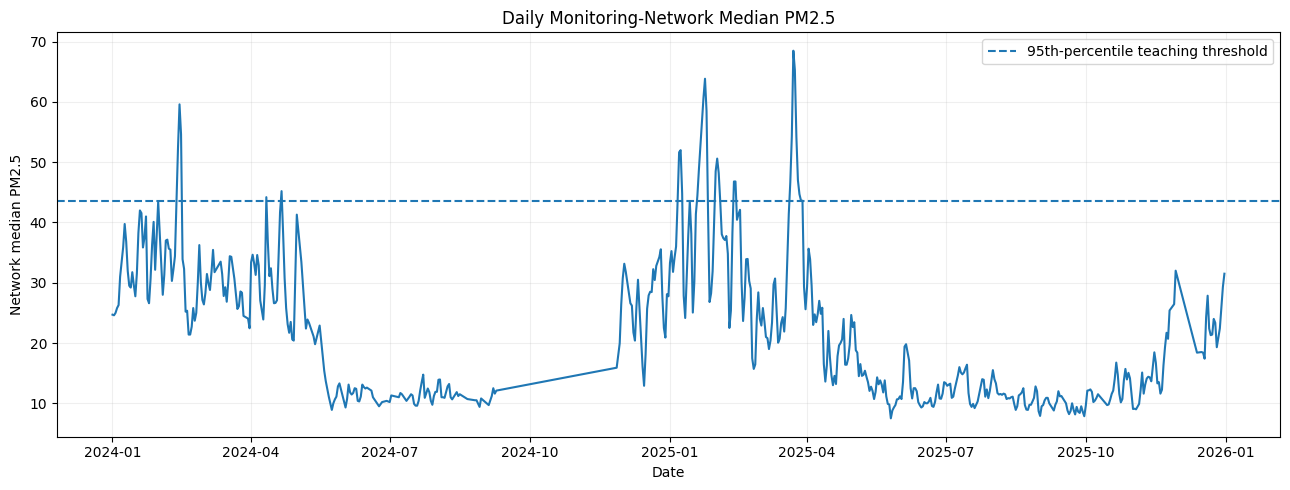

In [37]:
# CELL 37 — Network daily median time series

fig, ax = plt.subplots(
    figsize=(
        13,
        5,
    )
)

ax.plot(
    network_daily_valid[
        "date"
    ],
    network_daily_valid[
        "network_median_pm25"
    ],
)

ax.axhline(
    HIGH_EPISODE_THRESHOLD,
    linestyle="--",
    label="95th-percentile teaching threshold",
)

ax.set_xlabel(
    "Date"
)

ax.set_ylabel(
    "Network median PM2.5"
)

ax.set_title(
    "Daily Monitoring-Network Median PM2.5"
)

ax.grid(
    alpha=0.2
)

ax.legend()

fig.tight_layout()

NETWORK_DAILY_FIG = (
    FIGURE_DIR
    / "05_network_daily_median_PM25.png"
)

fig.savefig(
    NETWORK_DAILY_FIG,
    dpi=250,
    bbox_inches="tight",
)

plt.show()

# 5.18 Primary High-PM₂.₅ Episode Map

เลือกวันที่:

```text
network_median_pm25 สูงที่สุด
```

ในกลุ่ม high episodes

จากนั้น map ค่า PM₂.₅ ของสถานีในวันนั้น

แผนที่นี้ตอบ:

> station pattern ในวัน high-network-median episode เป็นอย่างไร?

ไม่ได้ตอบ:

> พื้นผิว PM₂.₅ ต่อเนื่องทั้งประเทศเป็นอย่างไร?

In [38]:
# CELL 38 — Select primary high episode

if len(
    high_episode_dates
) == 0:

    raise RuntimeError(
        "No high-episode dates were identified."
    )


PRIMARY_HIGH_EPISODE_DATE = (
    high_episode_dates[
        "date"
    ]
    .iloc[
        0
    ]
)


primary_episode = (
    pm25_spatiotemporal[
        pm25_spatiotemporal[
            "date"
        ].eq(
            PRIMARY_HIGH_EPISODE_DATE
        )
    ]
    .copy()
)


print(
    "Primary high episode:",
    PRIMARY_HIGH_EPISODE_DATE
)

print(
    "Stations available:",
    primary_episode[
        "station_id"
    ].nunique()
)

print(
    "Median PM2.5:",
    primary_episode[
        "pm25_mean"
    ].median()
)

print(
    "Maximum PM2.5:",
    primary_episode[
        "pm25_mean"
    ].max()
)

Primary high episode: 2025-03-23 00:00:00
Stations available: 99
Median PM2.5: 68.5
Maximum PM2.5: 129.6


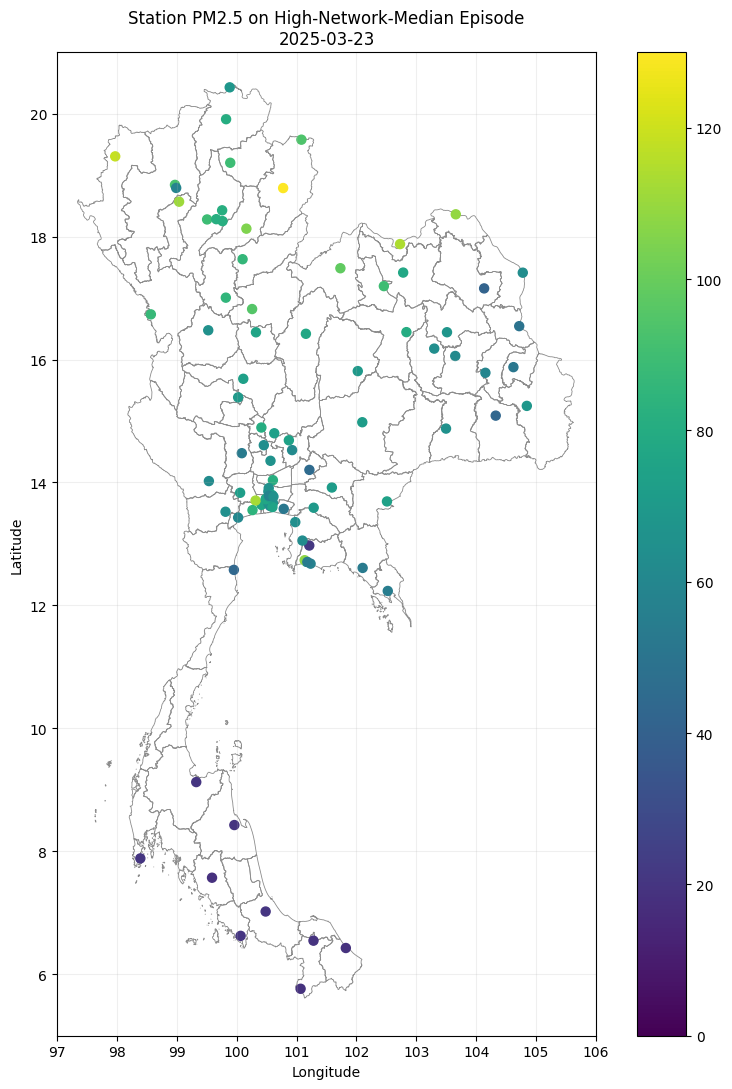

In [39]:
# CELL 39 — High-episode station map

EPISODE_VMIN = 0.0

EPISODE_VMAX = (
    np.ceil(
        primary_episode[
            "pm25_mean"
        ]
        .max()
        / 10
    )
    * 10
)


if (
    not np.isfinite(
        EPISODE_VMAX
    )
    or EPISODE_VMAX
    <= 0
):

    EPISODE_VMAX = 10.0


fig, ax = plt.subplots(
    figsize=(
        8.5,
        11,
    )
)

province.plot(
    ax=ax,
    facecolor="none",
    edgecolor="0.55",
    linewidth=0.6,
)

primary_episode.plot(
    ax=ax,
    column="pm25_mean",
    legend=True,
    markersize=42,
    vmin=EPISODE_VMIN,
    vmax=EPISODE_VMAX,
)

ax.set_xlim(
    97,
    106,
)

ax.set_ylim(
    5,
    21,
)

ax.set_xlabel(
    "Longitude"
)

ax.set_ylabel(
    "Latitude"
)

ax.set_title(
    (
        "Station PM2.5 on High-Network-Median Episode\n"
        + str(
            pd.Timestamp(
                PRIMARY_HIGH_EPISODE_DATE
            ).date()
        )
    )
)

ax.grid(
    alpha=0.2
)

fig.tight_layout()

EPISODE_MAP = (
    FIGURE_DIR
    / (
        "05_high_episode_PM25_"
        + str(
            pd.Timestamp(
                PRIMARY_HIGH_EPISODE_DATE
            ).date()
        )
        + ".png"
    )
)

fig.savefig(
    EPISODE_MAP,
    dpi=250,
    bbox_inches="tight",
)

plt.show()

In [40]:
# CELL 40 — Three-province values on the primary high episode

case_primary_episode = (
    primary_episode[
        primary_episode[
            "province_normalized"
        ]
        .isin(
            CASE_PROVINCE_MAP.keys()
        )
    ]
    .copy()
)


case_primary_episode[
    "case_province"
] = (
    case_primary_episode[
        "province_normalized"
    ]
    .map(
        CASE_PROVINCE_MAP
    )
)


display(
    case_primary_episode[
        [
            c
            for c
            in [
                "date",
                "station_id",
                "station_name_en",
                "case_province",
                "pm25_mean",
            ]
            if c
            in case_primary_episode.columns
        ]
    ]
    .sort_values(
        [
            "case_province",
            "pm25_mean",
        ],
        ascending=[
            True,
            False,
        ],
    )
)

,date,station_id,station_name_en,case_province,pm25_mean
69897,2025-03-23,99t,Meteorological Station Lopburi,Lop Buri,73.1
6924,2025-03-23,105t,Nakhon Nayok Municipality Public Health Servic...,Nakhon Nayok,44.9
23100,2025-03-23,24t,Na Phralan Police Station,Saraburi,74.8
23808,2025-03-23,25t,Khao Noi Fire Station,Saraburi,61.7


# 5.19 Nearest-WMO Distance as Monitoring-Network Context

ถ้ามี output จาก Notebook 04 เราจะเพิ่ม:

```text
nearest WMO ID
distance_km
```

เข้า station summary

แต่ยังไม่วิเคราะห์:

```text
temperature
RH
wind
rain
```

เพราะ Notebook 04 มีเพียง station relationship
ไม่ใช่ meteorological observations

In [41]:
# CELL 41 — Read nearest-WMO metadata if available

if (
    NEAREST_WMO_FILE is not None
    and NEAREST_WMO_FILE.exists()
):

    nearest_wmo = pd.read_csv(
        NEAREST_WMO_FILE,
        dtype={
            "station_id":
                "string",

            "wmo_id":
                "string",
        },
    )


    nearest_wmo[
        "station_id"
    ] = (
        nearest_wmo[
            "station_id"
        ]
        .astype(
            "string"
        )
        .str.strip()
        .str.lower()
    )


    wmo_context_fields = [
        c
        for c
        in [
            "station_id",
            "wmo_id",
            "met_station_name",
            "distance_km_geodesic",
            "azimuth_to_wmo_deg",
            "distance_class",
        ]
        if c
        in nearest_wmo.columns
    ]


    station_year_with_wmo = (
        station_year_pm25_gdf
        .merge(
            nearest_wmo[
                wmo_context_fields
            ],
            on="station_id",
            how="left",
            validate="many_to_one",
        )
    )


    station_year_with_wmo = (
        gpd.GeoDataFrame(
            station_year_with_wmo,
            geometry="geometry",
            crs=station_year_pm25_gdf.crs,
        )
    )


    print(
        "Station-year records with WMO metadata:",
        int(
            station_year_with_wmo[
                "wmo_id"
            ]
            .notna()
            .sum()
        ),
        "/",
        len(
            station_year_with_wmo
        )
    )

else:

    nearest_wmo = pd.DataFrame()

    station_year_with_wmo = (
        station_year_pm25_gdf.copy()
    )

    print(
        "Notebook 04 nearest-WMO metadata not found."
    )

Station-year records with WMO metadata: 195 / 201


In [42]:
# CELL 42 — Nearest-WMO distance by case province

if (
    len(
        nearest_wmo
    ) > 0
    and "province_name_en"
    in pcd_stations.columns
):

    station_wmo_context = (
        pcd_stations[
            [
                "station_id",
                "province_name_en",
            ]
        ]
        .merge(
            nearest_wmo[
                [
                    c
                    for c
                    in [
                        "station_id",
                        "wmo_id",
                        "met_station_name",
                        "distance_km_geodesic",
                        "distance_class",
                    ]
                    if c
                    in nearest_wmo.columns
                ]
            ],
            on="station_id",
            how="left",
            validate="one_to_one",
        )
    )


    station_wmo_context[
        "province_normalized"
    ] = (
        station_wmo_context[
            "province_name_en"
        ]
        .map(
            normalize_place_name
        )
    )


    case_wmo_context = (
        station_wmo_context[
            station_wmo_context[
                "province_normalized"
            ]
            .isin(
                CASE_PROVINCE_MAP.keys()
            )
        ]
        .copy()
    )


    case_wmo_context[
        "case_province"
    ] = (
        case_wmo_context[
            "province_normalized"
        ]
        .map(
            CASE_PROVINCE_MAP
        )
    )


    case_wmo_distance_summary = (
        case_wmo_context
        .groupby(
            "case_province"
        )
        .agg(
            pcd_station_n=(
                "station_id",
                "nunique",
            ),

            mean_nearest_wmo_km=(
                "distance_km_geodesic",
                "mean",
            ),

            median_nearest_wmo_km=(
                "distance_km_geodesic",
                "median",
            ),

            maximum_nearest_wmo_km=(
                "distance_km_geodesic",
                "max",
            ),
        )
        .reset_index()
    )


    display(
        case_wmo_distance_summary
    )

else:

    case_wmo_context = pd.DataFrame()

    case_wmo_distance_summary = (
        pd.DataFrame()
    )

,case_province,pcd_station_n,mean_nearest_wmo_km,median_nearest_wmo_km,maximum_nearest_wmo_km
0,Lop Buri,1,0.083885,0.083885,0.083885
1,Nakhon Nayok,1,7.825981,7.825981,7.825981
2,Saraburi,2,22.395260,22.395260,23.072906


# Interpretation

ถ้าจังหวัดหนึ่งมี nearest-WMO distance สูงกว่าอีกจังหวัดมาก

ไม่ได้แปลว่า:

> PM₂.₅ สูงกว่าเพราะ WMO อยู่ไกล

Distance นี้เป็น **data-support / network context**

มันบอกว่า:

> การเชื่อม PM₂.₅ กับข้อมูลอุตุนิยมวิทยาในพื้นที่นั้นอาจมี spatial representativeness uncertainty มากกว่า

In [43]:
# CELL 43 — Station-month PM2.5 statistics

station_month_pm25 = (
    pm25_spatiotemporal
    .groupby(
        [
            "station_id",
            "year",
            "month",
        ]
    )
    .agg(
        mean_pm25=(
            "pm25_mean",
            "mean",
        ),

        median_pm25=(
            "pm25_mean",
            "median",
        ),

        p90_pm25=(
            "pm25_mean",
            lambda x:
                x.quantile(
                    0.90
                ),
        ),

        station_day_n=(
            "date",
            "nunique",
        ),
    )
    .reset_index()
)


station_month_pm25 = (
    station_month_pm25
    .merge(
        station_month_coverage[
            [
                "station_id",
                "year",
                "month",
                "expected_days_in_month",
                "monthly_coverage_pct",
            ]
        ],
        on=[
            "station_id",
            "year",
            "month",
        ],
        how="left",
        validate="one_to_one",
    )
)


display(
    station_month_pm25.head(
        20
    )
)

,station_id,year,month,mean_pm25,median_pm25,p90_pm25,station_day_n,expected_days_in_month,monthly_coverage_pct
0,02t,2024,1,45.470968,42.80,61.30,31,31,100.000000
1,02t,2024,2,33.558621,28.50,59.46,29,29,100.000000
2,02t,2024,3,28.019355,26.30,37.10,31,31,100.000000
3,02t,2024,4,26.670000,25.40,35.45,30,30,100.000000
4,02t,2024,5,23.312903,19.10,39.70,31,31,100.000000
5,02t,2024,6,16.433333,16.65,19.86,30,30,100.000000
6,02t,2024,7,15.574194,15.20,18.90,31,31,100.000000
7,02t,2024,8,14.429032,13.80,17.40,31,31,100.000000
8,02t,2024,9,18.000000,17.10,23.19,30,30,100.000000
9,02t,2024,10,21.706452,21.30,30.80,31,31,100.000000


# 5.20 Advanced Check — Common Stations Across All Five Years

อีกวิธีลด network-composition bias คือ:

> ใช้เฉพาะสถานีที่มี data record ในทุกปี 2021–2025

นี่ไม่ได้รับประกัน completeness สูง
แต่ช่วยควบคุม station composition

เราจะใช้ร่วมกับ annual coverage threshold:

```text
station appears in all 5 years
AND
coverage >= 75% in each year
```

เรียกว่า:

```text
stable teaching panel
```

ไม่ใช่ formal panel model

In [44]:
# CELL 44 — Stable five-year station panel

EXPECTED_YEARS = [
    2021,
    2022,
    2023,
    2024,
    2025,
]


eligible_by_station = (
    station_year_coverage[
        station_year_coverage[
            "year"
        ]
        .isin(
            EXPECTED_YEARS
        )
    ]
    .groupby(
        "station_id"
    )
    .agg(
        year_n=(
            "year",
            "nunique",
        ),

        eligible_year_n=(
            "annual_coverage_eligible",
            "sum",
        ),
    )
    .reset_index()
)


stable_panel_station_ids = set(
    eligible_by_station.loc[
        (
            eligible_by_station[
                "year_n"
            ]
            == len(
                EXPECTED_YEARS
            )
        )
        &
        (
            eligible_by_station[
                "eligible_year_n"
            ]
            == len(
                EXPECTED_YEARS
            )
        ),
        "station_id",
    ]
)


print(
    "Stable five-year stations:",
    len(
        stable_panel_station_ids
    )
)

Stable five-year stations: 0


In [45]:
# CELL 45 — Annual PM2.5 for stable station panel

stable_panel_daily = (
    pm25_spatiotemporal[
        pm25_spatiotemporal[
            "station_id"
        ]
        .isin(
            stable_panel_station_ids
        )
    ]
    .copy()
)


stable_panel_annual = (
    stable_panel_daily
    .groupby(
        "year"
    )
    .agg(
        station_n=(
            "station_id",
            "nunique",
        ),

        station_day_n=(
            "pm25_mean",
            "count",
        ),

        mean_pm25=(
            "pm25_mean",
            "mean",
        ),

        median_pm25=(
            "pm25_mean",
            "median",
        ),
    )
    .reset_index()
)


display(
    stable_panel_annual
)

,year,station_n,station_day_n,mean_pm25,median_pm25


In [46]:
# CELL 46 — Compare all-data and stable-panel annual means

if len(
    stable_panel_annual
) > 0:

    stable_comparison = (
        annual_all[
            [
                "year",
                "mean_pm25",
            ]
        ]
        .rename(
            columns={
                "mean_pm25":
                    "all_available_mean"
            }
        )
        .merge(
            stable_panel_annual[
                [
                    "year",
                    "mean_pm25",
                ]
            ]
            .rename(
                columns={
                    "mean_pm25":
                        "stable_panel_mean"
                }
            ),
            on="year",
            how="left",
        )
    )


    fig, ax = plt.subplots(
        figsize=(
            9,
            5,
        )
    )

    ax.plot(
        stable_comparison[
            "year"
        ],
        stable_comparison[
            "all_available_mean"
        ],
        marker="o",
        label="All available",
    )

    ax.plot(
        stable_comparison[
            "year"
        ],
        stable_comparison[
            "stable_panel_mean"
        ],
        marker="s",
        label="Stable five-year panel",
    )

    ax.set_xlabel(
        "Year"
    )

    ax.set_ylabel(
        "Mean daily PM2.5"
    )

    ax.set_title(
        "Annual PM2.5 — Monitoring-Network Composition Sensitivity"
    )

    ax.grid(
        alpha=0.25
    )

    ax.legend()

    fig.tight_layout()

    STABLE_PANEL_FIG = (
        FIGURE_DIR
        / "05_annual_PM25_stable_panel_comparison.png"
    )

    fig.savefig(
        STABLE_PANEL_FIG,
        dpi=250,
        bbox_inches="tight",
    )

    plt.show()

else:

    stable_comparison = pd.DataFrame()

    print(
        "No station satisfies the strict stable-panel criterion."
    )

No station satisfies the strict stable-panel criterion.


# Interpretation of the Stable Panel

ถ้า all-available กับ stable-panel มี pattern คล้ายกัน:

> annual pattern มีความ robust ต่อ station composition มากขึ้น

ถ้า pattern ต่างกัน:

> network composition เป็นปัจจัยสำคัญในการตีความ multi-year variation

แต่ทั้งสองกรณียังไม่ใช่ causal trend analysis

# 5.21 Export Analysis-Ready Spatiotemporal Products

สร้าง CSV:

```text
05_station_year_PM25.csv
05_station_month_PM25.csv
05_station_year_coverage.csv
05_station_month_coverage.csv
05_annual_PM25_all.csv
05_annual_PM25_eligible.csv
05_monthly_PM25.csv
05_seasonal_PM25.csv
05_station_season_PM25.csv
05_three_province_annual_PM25.csv
05_three_province_monthly_PM25.csv
05_three_province_seasonal_PM25.csv
05_network_daily_PM25.csv
05_high_episode_dates.csv
05_primary_high_episode_station_values.csv
05_stable_panel_annual_PM25.csv
```

และ GeoPackage:

```text
05_spatiotemporal_airquality.gpkg
```

layers:

```text
station_year_pm25
station_season_pm25
primary_high_episode
```

In [47]:
# CELL 47 — Save CSV outputs

CSV_OUTPUTS = {
    "05_station_year_PM25.csv":
        station_year_pm25_gdf.drop(
            columns="geometry",
            errors="ignore",
        ),

    "05_station_month_PM25.csv":
        station_month_pm25,

    "05_station_year_coverage.csv":
        station_year_coverage,

    "05_station_month_coverage.csv":
        station_month_coverage,

    "05_coverage_summary_by_year.csv":
        coverage_summary_by_year,

    "05_annual_PM25_all.csv":
        annual_all,

    "05_annual_PM25_eligible.csv":
        annual_eligible,

    "05_annual_PM25_comparison.csv":
        annual_comparison,

    "05_monthly_PM25.csv":
        monthly_pm25,

    "05_seasonal_PM25.csv":
        seasonal_pm25,

    "05_station_season_PM25.csv":
        station_season_pm25_gdf.drop(
            columns="geometry",
            errors="ignore",
        ),

    "05_three_province_annual_PM25.csv":
        case_annual_summary,

    "05_three_province_monthly_PM25.csv":
        case_monthly_summary,

    "05_three_province_seasonal_PM25.csv":
        case_seasonal_summary,

    "05_network_daily_PM25.csv":
        network_daily,

    "05_network_daily_valid_for_episode_detection.csv":
        network_daily_valid,

    "05_high_episode_dates.csv":
        high_episode_dates,

    "05_primary_high_episode_station_values.csv":
        primary_episode.drop(
            columns="geometry",
            errors="ignore",
        ),

    "05_stable_panel_station_eligibility.csv":
        eligible_by_station,

    "05_stable_panel_annual_PM25.csv":
        stable_panel_annual,

    "05_annual_map_inventory.csv":
        annual_map_inventory,
}


if len(
    case_wmo_distance_summary
) > 0:

    CSV_OUTPUTS[
        "05_case_nearest_WMO_distance_summary.csv"
    ] = (
        case_wmo_distance_summary
    )


for filename, table in CSV_OUTPUTS.items():

    path = (
        OUTPUT_DIR
        / filename
    )

    table.to_csv(
        path,
        index=False,
        encoding="utf-8-sig",
    )

    print(
        "Saved:",
        filename
    )

Saved: 05_station_year_PM25.csv
Saved: 05_station_month_PM25.csv
Saved: 05_station_year_coverage.csv
Saved: 05_station_month_coverage.csv
Saved: 05_coverage_summary_by_year.csv
Saved: 05_annual_PM25_all.csv
Saved: 05_annual_PM25_eligible.csv
Saved: 05_annual_PM25_comparison.csv
Saved: 05_monthly_PM25.csv
Saved: 05_seasonal_PM25.csv
Saved: 05_station_season_PM25.csv
Saved: 05_three_province_annual_PM25.csv
Saved: 05_three_province_monthly_PM25.csv
Saved: 05_three_province_seasonal_PM25.csv
Saved: 05_network_daily_PM25.csv
Saved: 05_network_daily_valid_for_episode_detection.csv
Saved: 05_high_episode_dates.csv
Saved: 05_primary_high_episode_station_values.csv
Saved: 05_stable_panel_station_eligibility.csv
Saved: 05_stable_panel_annual_PM25.csv
Saved: 05_annual_map_inventory.csv
Saved: 05_case_nearest_WMO_distance_summary.csv


In [48]:
# CELL 48 — Save GeoPackage outputs

SPATIOTEMPORAL_GPKG = (
    OUTPUT_DIR
    / "05_spatiotemporal_airquality.gpkg"
)


if SPATIOTEMPORAL_GPKG.exists():

    SPATIOTEMPORAL_GPKG.unlink()


station_year_pm25_gdf.to_file(
    SPATIOTEMPORAL_GPKG,
    layer="station_year_pm25",
    driver="GPKG",
)


station_season_pm25_gdf.to_file(
    SPATIOTEMPORAL_GPKG,
    layer="station_season_pm25",
    driver="GPKG",
    mode="a",
)


primary_episode.to_file(
    SPATIOTEMPORAL_GPKG,
    layer="primary_high_episode",
    driver="GPKG",
    mode="a",
)


print(
    "Saved:",
    SPATIOTEMPORAL_GPKG
)

Saved: /content/drive/MyDrive/Teaching_PCD_Environmental_GIS/02_output/Notebook_05/05_spatiotemporal_airquality.gpkg


# 5.22 Final Notebook Checkpoint

Notebook 05 พร้อมสำหรับ spatial statistics เมื่อ:

```text
daily PM2.5 + geometry ready
station-year completeness computed
station-year summaries ready
annual maps use common scale
monthly summaries ready
seasonal summaries ready
three-province data ready
high-episode dates identified
outputs saved
```

Stable five-year panel เป็น advanced sensitivity check
จึงไม่จำเป็นต้องมี station เสมอไปเพื่อให้ Notebook ผ่าน

In [49]:
# CELL 49 — Final Notebook 05 checkpoint

station_year_ready = (
    len(
        station_year_pm25_gdf
    ) > 0
)


coverage_ready = (
    station_year_coverage[
        "calendar_year_coverage_pct"
    ]
    .notna()
    .any()
)


common_scale_ready = (
    len(
        annual_map_inventory
    ) > 0
    and annual_map_inventory[
        "vmin"
    ].nunique()
    == 1
    and annual_map_inventory[
        "vmax"
    ].nunique()
    == 1
)


monthly_ready = (
    len(
        monthly_pm25
    ) == 12
)


seasonal_ready = (
    seasonal_pm25[
        "season_teaching"
    ]
    .notna()
    .sum()
    >= 3
)


case_ready = (
    len(
        case_daily
    ) > 0
)


episode_ready = (
    len(
        high_episode_dates
    ) > 0
)


gpkg_ready = (
    SPATIOTEMPORAL_GPKG.exists()
)


final_checks = pd.DataFrame([
    {
        "check":
            "Station-day GeoDataFrame",

        "status":
            (
                "PASS"
                if len(
                    pm25_spatiotemporal
                ) > 0
                else "FAIL"
            ),

        "detail":
            str(
                len(
                    pm25_spatiotemporal
                )
            ),
    },

    {
        "check":
            "Station-year summaries",

        "status":
            (
                "PASS"
                if station_year_ready
                else "FAIL"
            ),

        "detail":
            str(
                len(
                    station_year_pm25_gdf
                )
            ),
    },

    {
        "check":
            "Completeness metrics",

        "status":
            (
                "PASS"
                if coverage_ready
                else "FAIL"
            ),

        "detail":
            (
                f"threshold = "
                f"{MIN_ANNUAL_COVERAGE_PCT:.0f}%"
            ),
    },

    {
        "check":
            "Common annual map scale",

        "status":
            (
                "PASS"
                if common_scale_ready
                else "FAIL"
            ),

        "detail":
            (
                f"{MAP_VMIN:.1f}–"
                f"{MAP_VMAX:.1f}"
            ),
    },

    {
        "check":
            "Monthly summaries",

        "status":
            (
                "PASS"
                if monthly_ready
                else "FAIL"
            ),

        "detail":
            str(
                len(
                    monthly_pm25
                )
            ),
    },

    {
        "check":
            "Seasonal summaries",

        "status":
            (
                "PASS"
                if seasonal_ready
                else "FAIL"
            ),

        "detail":
            str(
                len(
                    seasonal_pm25
                )
            ),
    },

    {
        "check":
            "Three-province case",

        "status":
            (
                "PASS"
                if case_ready
                else "FAIL"
            ),

        "detail":
            (
                f"{case_daily['station_id'].nunique()} stations"
            ),
    },

    {
        "check":
            "High-episode detection",

        "status":
            (
                "PASS"
                if episode_ready
                else "FAIL"
            ),

        "detail":
            str(
                len(
                    high_episode_dates
                )
            ),
    },

    {
        "check":
            "Spatiotemporal GeoPackage",

        "status":
            (
                "PASS"
                if gpkg_ready
                else "FAIL"
            ),

        "detail":
            str(
                SPATIOTEMPORAL_GPKG
            ),
    },
])


display(
    final_checks
)


if final_checks[
    "status"
].eq(
    "PASS"
).all():

    print(
        "\n=========================================="
    )

    print(
        "NOTEBOOK 05 SPATIOTEMPORAL ANALYSIS READY"
    )

    print(
        "=========================================="
    )

else:

    print(
        "\nCHECK NOTEBOOK 05 RESULTS "
        "BEFORE CONTINUING"
    )

,check,status,detail
0,Station-day GeoDataFrame,PASS,70173
1,Station-year summaries,PASS,201
2,Completeness metrics,PASS,threshold = 75%
3,Common annual map scale,PASS,0.0–40.0
4,Monthly summaries,PASS,12
5,Seasonal summaries,PASS,3
6,Three-province case,PASS,4 stations
7,High-episode detection,PASS,28
8,Spatiotemporal GeoPackage,PASS,/content/drive/MyDrive/Teaching_PCD_Environmen...



NOTEBOOK 05 SPATIOTEMPORAL ANALYSIS READY


# แบบฝึกหัดท้ายบท

## Exercise 1 — Completeness

เลือก station 2 แห่ง:

```text
coverage สูง 1 แห่ง
coverage ต่ำ 1 แห่ง
```

สำหรับปีเดียวกัน

รายงาน:

```text
observed days
calendar-year coverage
mean PM2.5
median PM2.5
```

อภิปรายว่าทำไม mean อย่างเดียวไม่เพียงพอ

---

## Exercise 2 — Network Change

จาก `coverage_summary_by_year`

ตอบ:

1. ปีใดมี station มากที่สุด?
2. ปีใดมี eligible station มากที่สุด?
3. median coverage เปลี่ยนอย่างไร?
4. annual PM₂.₅ comparison อาจได้รับผลจาก network change หรือไม่?

---

## Exercise 3 — Same Map Scale

เปิด annual maps 2 ปี

ตรวจ:

```text
vmin
vmax
```

แล้วอธิบายว่า:

> ทำไม annual maps ที่ auto-scale แยกกันจึงอาจทำให้ผู้ดูเข้าใจผิด?

---

## Exercise 4 — Monthly Pattern

จาก monthly summary:

1. เดือนไหน mean สูงที่สุด?
2. เดือนไหน median สูงที่สุด?
3. เดือนไหน P90 สูงที่สุด?
4. mean กับ median ต่างกันมากในเดือนไหน?
5. สิ่งนี้บอกอะไรเกี่ยวกับ distribution?

---

## Exercise 5 — Dry vs Wet

เปรียบเทียบ:

```text
Dry (Nov-Apr)
Wet (Jun-Oct)
Transition (May)
```

ด้วย:

```text
mean
median
P90
station-day n
```

ห้ามเขียนว่า:

> “dry season causes high PM2.5”

เพียงจาก summary นี้

ให้เขียนเป็น:

> descriptive association/pattern

---

## Exercise 6 — Three Provinces

สร้างตารางสำหรับ:

```text
Saraburi
Lop Buri
Nakhon Nayok
```

เปรียบเทียบ:

```text
annual mean
monthly mean
seasonal mean
station_n
station_day_n
```

แล้วอภิปรายข้อจำกัดจากจำนวนสถานี

---

## Exercise 7 — High Episode

เลือก primary high episode

ตอบ:

1. วันที่ใด?
2. network median เท่าไร?
3. มีสถานีกี่แห่ง?
4. station สูงสุดคือที่ใด?
5. 3 จังหวัดกรณีศึกษามีข้อมูลหรือไม่?
6. แผนที่นี้เป็น continuous PM₂.₅ surface หรือไม่?

---

## Exercise 8 — Percentile ≠ Standard

อธิบายความแตกต่าง:

```text
95th percentile teaching episode
```

กับ:

```text
regulatory air-quality standard exceedance
```

อย่างน้อย 4 ประเด็น

---

## Exercise 9 — Stable Panel

ถ้ามี stable five-year panel:

เปรียบเทียบ:

```text
all-available annual mean
stable-panel annual mean
```

ถ้าแตกต่างกัน ให้อธิบายว่า monitoring-network composition มีบทบาทอย่างไร

ถ้าไม่มี stable panel:

อธิบายว่าทำไม criterion จึง strict เกินไปสำหรับ dataset นี้ได้

---

## Exercise 10 — Nearest WMO Context

หากมี Notebook 04 output:

เปรียบเทียบ nearest-WMO distance ของ 3 จังหวัด

อภิปราย:

> จังหวัดที่ WMO อยู่ไกลกว่าอาจมี uncertainty แบบใดเมื่อเราจะนำ meteorological observations มาเชื่อมกับ PM₂.₅?

# Common Mistakes

## Mistake 1 — Annual map แต่ละปีใช้ color scale คนละช่วง

ทำให้ visual comparison ไม่เที่ยงตรง

---

## Mistake 2 — Station mean = Province mean

ไม่จริงโดยอัตโนมัติ

---

## Mistake 3 — ไม่มี station = PM₂.₅ ต่ำ

ไม่จริง

ไม่มี station หมายถึงไม่มี measurement point ใน dataset

---

## Mistake 4 — Data coverage ต่ำแต่ตีความเหมือน station ที่ coverage สูง

ควรรายงาน completeness

---

## Mistake 5 — เรียก 2021–2025 ว่า climatology

ไม่ควรทำโดยอัตโนมัติ

---

## Mistake 6 — High percentile = regulatory exceedance

คนละแนวคิด

---

## Mistake 7 — Dry season มี PM₂.₅ สูง จึงสรุปว่า season “เป็นสาเหตุ”

Descriptive pattern ≠ causation

---

## Mistake 8 — Nearest WMO distance เป็นตัวแปรอุตุนิยมวิทยา

ไม่ใช่

เป็น network/spatial-support metadata

# สิ่งที่ต้องจำจาก Notebook 05

```text
Spatiotemporal analysis
=
Where
+
When
+
How much
+
How complete
```

และการอ่านแผนที่หลายปีอย่างถูกต้องต้องคำนึงถึง:

```text
same map scale
station availability
data completeness
network composition
point-observation limitation
```

ก่อนตีความ temporal trend หรือ spatial pattern

# Notebook ต่อไป

## Notebook 06 — Spatial Statistics and Mini Research

ชื่อที่แนะนำ:

```text
06_spatial_statistics_and_mini_research.ipynb
```

จะใช้ station-level spatial summaries จาก Notebook 05 เพื่อเรียน:

```text
Spatial weights
K-nearest neighbors
Distance band
Global Moran's I
Moran scatterplot
Local Moran / LISA
High–High
Low–Low
High–Low
Low–High
Permutation test
Sensitivity to k
Multiple-testing caution
```

พร้อมหลักสำคัญ:

> Spatial clustering of monitoring stations  
> ไม่เท่ากับ continuous pollution hotspot surface

และจะปิด course ด้วย mini-research workflow:

```text
Research Question
→ Data
→ QC
→ Temporal Aggregation
→ Geometry
→ Spatial Relationships
→ Mapping
→ Spatial Statistics
→ Interpretation
→ Limitations
→ Reproducibility
```